# 🧠 BraTS 2020 — Brain Tumor Segmentation, Risk Analysis & 3D Visualization
**Complete pipeline (A → Z)**

| Part | Content |
|---|---|
| 1 | Setup, configuration, dataset discovery |
| 2 | Data understanding (EDA) |
| 3 | Preprocessing + caching |
| 4 | Train / val / test split + 3D patch dataset + augmentation |
| 5 | Model: 3D Residual Attention U-Net (deep supervision) |
| 6 | Loss, metrics, sliding-window inference |
| 7 | Training loop |
| 8 | Evaluation on held-out test patients |
| 9 | Tumor size + risk analysis |
| 10 | 3D reconstruction **together with the source MRI** (static + interactive) |
| 11 | One-call inference: give a patient path → size, risk, 3D report |
| 12 | Predict the unlabeled BraTS validation set |

> ⚠️ The risk score is a **research heuristic** computed from the segmentation.
> It is **not** a medical diagnosis.

In [1]:
# ============================================================
# PART 1 — SETUP & CONFIGURATION
# ============================================================
import os, re, gc, sys, glob, json, math, time, random, warnings
from pathlib import Path
from collections import OrderedDict

import numpy as np
import pandas as pd
import nibabel as nib
import matplotlib
import matplotlib.pyplot as plt
from scipy import ndimage as ndi
from skimage import measure

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

try:
    from tqdm.auto import tqdm
except Exception:                       # tqdm missing -> no-op wrapper
    def tqdm(x, **kw):
        return x

warnings.filterwarnings("ignore")


class CFG:
    # ---------- paths ----------
    # Kaggle default. Override with env var BRATS_ROOT if you run elsewhere.
    TRAIN_ROOT = os.environ.get(
        "BRATS_TRAIN_ROOT",
        "/kaggle/input/datasets/awsaf49/brats20-dataset-training-validation/"
        "BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData")
    VAL_ROOT = os.environ.get(
        "BRATS_VAL_ROOT",
        "/kaggle/input/datasets/awsaf49/brats20-dataset-training-validation/"
        "BraTS2020_ValidationData/MICCAI_BraTS2020_ValidationData")
    WORK_DIR = os.environ.get("BRATS_WORK_DIR", "/kaggle/working")
    CACHE_DIR = os.path.join(WORK_DIR, "cache")
    OUT_DIR = os.path.join(WORK_DIR, "outputs")
    CKPT_DIR = os.path.join(WORK_DIR, "checkpoints")

    # ---------- data ----------
    MODALITIES = ["flair", "t1", "t1ce", "t2"]          # channel order (fixed!)
    MAX_PATIENTS = None            # e.g. 40 for a quick debug run, None = all
    SPLIT = (0.80, 0.10, 0.10)     # train / val / test
    SEED = 42

    # ---------- model / training ----------
    PATCH = (128, 128, 128)        # lower to (96,96,96) if GPU memory is small
    BASE_FILTERS = 16              # 16 -> ~5M params, 24/32 -> bigger/better
    BATCH_SIZE = 2
    NUM_WORKERS = 2
    EPOCHS = 100
    ITERS_PER_EPOCH = 200          # samples per "epoch" = ITERS * BATCH
    LR = 3e-4
    WEIGHT_DECAY = 1e-5
    WARMUP_EPOCHS = 3
    FG_PROB = 0.67                 # prob. that a patch is centred on tumor
    AMP = True
    GRAD_CLIP = 12.0
    VAL_EVERY = 5                  # validate every N epochs
    VAL_MAX_PATIENTS = 12          # patients used in the periodic validation
    SW_OVERLAP_VAL = 0.25
    SW_OVERLAP_TEST = 0.5
    TTA = True                     # flip test-time augmentation at test time
    EARLY_STOP_PATIENCE = 8        # in validation rounds

    # ---------- display ----------
    DISPLAY_MODALITY = "flair"     # MRI shown next to the 3D reconstruction


# Smoke-test switch (tiny run to check that the pipeline works end-to-end)
if os.environ.get("BRATS_SMOKE", "0") == "1":
    CFG.PATCH = (32, 32, 32); CFG.BASE_FILTERS = 8; CFG.BATCH_SIZE = 2
    CFG.NUM_WORKERS = 0; CFG.EPOCHS = 2; CFG.ITERS_PER_EPOCH = 4
    CFG.VAL_EVERY = 1; CFG.VAL_MAX_PATIENTS = 2; CFG.WARMUP_EPOCHS = 1
    CFG.AMP = False

for d in (CFG.WORK_DIR, CFG.CACHE_DIR, CFG.OUT_DIR, CFG.CKPT_DIR):
    os.makedirs(d, exist_ok=True)


def seed_everything(seed=CFG.SEED):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = True


seed_everything()
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device :", DEVICE, (torch.cuda.get_device_name(0) if DEVICE.type == "cuda" else ""))
print("Torch  :", torch.__version__)

# BraTS label convention in the raw files: 0 = background, 1 = NCR/NET (necrotic core),
# 2 = ED (edema), 4 = ET (enhancing tumor).  We remap 4 -> 3 internally.
LABEL_NAMES = {0: "Background", 1: "NCR/NET (necrotic core)", 2: "ED (edema)", 4: "ET (enhancing)"}
REGIONS = ["WT", "TC", "ET"]   # Whole Tumor = 1+2+4 | Tumor Core = 1+4 | Enhancing = 4

Device : cuda Tesla T4
Torch  : 2.11.0+cu128


In [2]:
# ============================================================
# PART 1b — DATASET DISCOVERY (robust file finder)
# ============================================================
def _is_nifti(name):
    n = name.lower()
    return n.endswith(".nii") or n.endswith(".nii.gz")


def find_patient_files(pdir):
    """Return dict modality -> path (+ 'seg' if present) for one patient folder.

    Robust to: .nii / .nii.gz, and the odd BraTS20_Training_355 file whose
    segmentation is named like 'W39_1998.09.19_Segm.nii'.
    """
    files = [f for f in os.listdir(pdir) if _is_nifti(f)]
    out = {}
    for f in files:
        low = f.lower()
        stem = re.sub(r"\.nii(\.gz)?$", "", low)
        if "seg" in stem:
            out["seg"] = os.path.join(pdir, f)
        elif stem.endswith("t1ce"):
            out["t1ce"] = os.path.join(pdir, f)
        elif stem.endswith("flair"):
            out["flair"] = os.path.join(pdir, f)
        elif stem.endswith("t2"):
            out["t2"] = os.path.join(pdir, f)
        elif stem.endswith("t1"):
            out["t1"] = os.path.join(pdir, f)
    return out


def discover_patients(root, need_seg=True):
    """List valid patient dicts: {'id','dir','files'}."""
    if not os.path.isdir(root):
        raise FileNotFoundError(f"Folder not found: {root}")
    patients, skipped = [], []
    for name in sorted(os.listdir(root)):
        pdir = os.path.join(root, name)
        if not os.path.isdir(pdir):
            continue
        files = find_patient_files(pdir)
        ok = all(m in files for m in CFG.MODALITIES) and (("seg" in files) or not need_seg)
        if ok:
            patients.append({"id": name, "dir": pdir, "files": files})
        else:
            skipped.append(name)
    return patients, skipped


train_patients_all, skipped = discover_patients(CFG.TRAIN_ROOT, need_seg=True)
if CFG.MAX_PATIENTS:
    train_patients_all = train_patients_all[:CFG.MAX_PATIENTS]
print(f"Training patients found : {len(train_patients_all)}   (skipped/incomplete: {len(skipped)})")
if skipped:
    print("Skipped:", skipped[:10])

try:
    val_patients_unlabeled, _ = discover_patients(CFG.VAL_ROOT, need_seg=False)
    print(f"Unlabeled validation patients : {len(val_patients_unlabeled)}")
except Exception as e:
    val_patients_unlabeled = []
    print("Validation folder not available:", e)

# Optional metadata CSVs shipped with BraTS2020 training data
meta_name_map, meta_survival = None, None
p = os.path.join(CFG.TRAIN_ROOT, "name_mapping.csv")
if os.path.exists(p):
    meta_name_map = pd.read_csv(p)
p = os.path.join(CFG.TRAIN_ROOT, "survival_info.csv")
if os.path.exists(p):
    meta_survival = pd.read_csv(p)
print("name_mapping.csv :", None if meta_name_map is None else meta_name_map.shape)
print("survival_info.csv:", None if meta_survival is None else meta_survival.shape)

Training patients found : 369   (skipped/incomplete: 0)
Unlabeled validation patients : 125
name_mapping.csv : (369, 6)
survival_info.csv: (236, 4)


In [3]:
# ============================================================
# PART 1c — LOADING HELPERS (canonical RAS orientation everywhere)
# ============================================================
def load_nifti_canonical(path):
    """Load NIfTI, reorient to closest-canonical (RAS+). Returns (data float32, zooms, affine)."""
    img = nib.as_closest_canonical(nib.load(path))
    data = np.asarray(img.dataobj, dtype=np.float32)
    zooms = tuple(float(z) for z in img.header.get_zooms()[:3])
    return data, zooms, img.affine


def load_patient_raw(files, with_seg=True):
    """Return vol (4,X,Y,Z) float32 in CFG.MODALITIES order, seg (X,Y,Z) uint8 or None, zooms, affine."""
    chans, zooms, affine = [], None, None
    for m in CFG.MODALITIES:
        d, z, a = load_nifti_canonical(files[m])
        chans.append(d)
        if zooms is None:
            zooms, affine = z, a
    vol = np.stack(chans, 0)
    seg = None
    if with_seg and "seg" in files:
        s, _, _ = load_nifti_canonical(files["seg"])
        seg = np.rint(s).astype(np.uint8)
        seg[seg == 4] = 3                    # 4 -> 3  (labels now 0,1,2,3)
    return vol, seg, zooms, affine


def seg_to_regions(seg):
    """label map (0,1,2,3 with 3=ET) -> binary region stack (3,X,Y,Z): WT, TC, ET."""
    wt = seg > 0
    tc = (seg == 1) | (seg == 3)
    et = seg == 3
    return np.stack([wt, tc, et], 0).astype(np.uint8)


def regions_to_seg(wt, tc, et):
    """binary regions -> label map using BraTS raw labels (1,2,4)."""
    out = np.zeros(wt.shape, np.uint8)
    out[wt] = 2
    out[tc] = 1
    out[et] = 4
    return out


def norm01(x):
    x = x.astype(np.float32)
    lo, hi = np.percentile(x, 1), np.percentile(x, 99)
    return np.clip((x - lo) / (hi - lo + 1e-8), 0, 1)

# PART 2 — Data Understanding (EDA)
Before touching a model we need to know: image size, voxel spacing, intensity ranges per
modality, how rare each tumor class is, how large tumors are, and how patients differ.

In [4]:
# ---------- 2.1 Scan inventory: shapes, spacing, intensity, brain size, labels ----------
def eda_one_patient(pt):
    vol, seg, zooms, _ = load_patient_raw(pt["files"], with_seg=True)
    brain = np.any(vol != 0, axis=0)
    vox_cm3 = float(np.prod(zooms)) / 1000.0
    row = {"id": pt["id"], "shape": vol.shape[1:], "spacing": zooms,
           "brain_cm3": brain.sum() * vox_cm3}
    for i, m in enumerate(CFG.MODALITIES):
        v = vol[i][brain]
        row[f"{m}_mean"], row[f"{m}_std"] = float(v.mean()), float(v.std())
        row[f"{m}_p99"], row[f"{m}_max"] = float(np.percentile(v, 99)), float(v.max())
    row["ncr_cm3"] = (seg == 1).sum() * vox_cm3
    row["ed_cm3"] = (seg == 2).sum() * vox_cm3
    row["et_cm3"] = (seg == 3).sum() * vox_cm3
    row["wt_cm3"] = (seg > 0).sum() * vox_cm3
    row["tc_cm3"] = row["ncr_cm3"] + row["et_cm3"]
    row["tumor_pct_brain"] = 100.0 * row["wt_cm3"] / max(row["brain_cm3"], 1e-6)
    row["tumor_slices"] = int((seg > 0).any(axis=(0, 1)).sum())
    row["has_et"] = bool(row["et_cm3"] > 0)
    return row


EDA_N = min(len(train_patients_all), 369)        # set lower (e.g. 60) for a faster EDA
eda_rows = [eda_one_patient(p) for p in tqdm(train_patients_all[:EDA_N], desc="EDA scan")]
eda = pd.DataFrame(eda_rows)
eda.to_csv(os.path.join(CFG.OUT_DIR, "eda_summary.csv"), index=False)

print("Volume shapes  :", eda["shape"].value_counts().to_dict())
print("Voxel spacings :", eda["spacing"].value_counts().to_dict())
print("\nTumor volume statistics (cm³):")
print(eda[["wt_cm3", "tc_cm3", "ed_cm3", "ncr_cm3", "et_cm3", "tumor_pct_brain"]].describe().round(2))
print(f"\nPatients without enhancing tumor: {(~eda['has_et']).sum()} / {len(eda)}")

EDA scan:   0%|          | 0/369 [00:00<?, ?it/s]

Volume shapes  : {(240, 240, 155): 369}
Voxel spacings : {(1.0, 1.0, 1.0): 369}

Tumor volume statistics (cm³):
       wt_cm3  tc_cm3  ed_cm3  ncr_cm3  et_cm3  tumor_pct_brain
count  369.00  369.00  369.00   369.00  369.00           369.00
mean    99.55   41.82   57.73    22.12   19.70             6.89
std     59.43   35.34   40.12    29.86   19.02             4.06
min      7.28    0.56    0.00     0.00    0.00             0.45
25%     50.74   14.25   25.66     3.87    4.52             3.46
50%     90.74   33.81   49.56    10.56   15.09             6.17
75%    145.12   60.04   80.43    25.39   30.14            10.17
max    361.78  190.19  213.96   189.15  111.25            22.44

Patients without enhancing tumor: 27 / 369


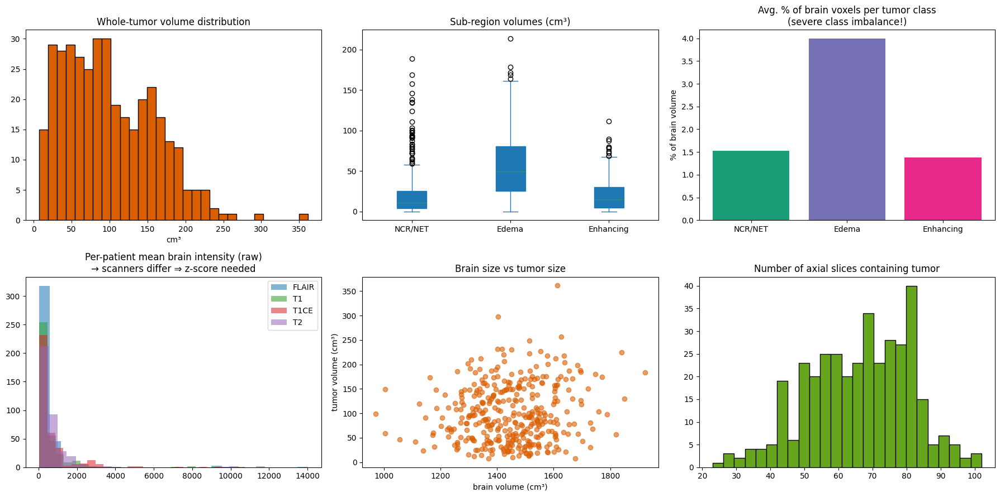

In [5]:
# ---------- 2.2 Plots: volumes, class balance, intensity ----------
fig, ax = plt.subplots(2, 3, figsize=(18, 9))

ax[0, 0].hist(eda["wt_cm3"], bins=30, color="#d95f02", edgecolor="k")
ax[0, 0].set_title("Whole-tumor volume distribution"); ax[0, 0].set_xlabel("cm³")

eda[["ncr_cm3", "ed_cm3", "et_cm3"]].plot.box(ax=ax[0, 1], patch_artist=True)
ax[0, 1].set_title("Sub-region volumes (cm³)")
ax[0, 1].set_xticklabels(["NCR/NET", "Edema", "Enhancing"])

mean_frac = {"Background": 100 - eda["tumor_pct_brain"].mean(),
             "NCR/NET": 100 * (eda["ncr_cm3"] / eda["brain_cm3"]).mean(),
             "Edema": 100 * (eda["ed_cm3"] / eda["brain_cm3"]).mean(),
             "Enhancing": 100 * (eda["et_cm3"] / eda["brain_cm3"]).mean()}
tumor_only = {k: v for k, v in mean_frac.items() if k != "Background"}
ax[0, 2].bar(tumor_only.keys(), tumor_only.values(), color=["#1b9e77", "#7570b3", "#e7298a"])
ax[0, 2].set_title("Avg. % of brain voxels per tumor class\n(severe class imbalance!)")
ax[0, 2].set_ylabel("% of brain volume")

for m, c in zip(CFG.MODALITIES, ["#1f77b4", "#2ca02c", "#d62728", "#9467bd"]):
    ax[1, 0].hist(eda[f"{m}_mean"], bins=25, alpha=0.55, label=m.upper(), color=c)
ax[1, 0].set_title("Per-patient mean brain intensity (raw)\n→ scanners differ ⇒ z-score needed")
ax[1, 0].legend()

ax[1, 1].scatter(eda["brain_cm3"], eda["wt_cm3"], alpha=0.6, c="#d95f02")
ax[1, 1].set_xlabel("brain volume (cm³)"); ax[1, 1].set_ylabel("tumor volume (cm³)")
ax[1, 1].set_title("Brain size vs tumor size")

ax[1, 2].hist(eda["tumor_slices"], bins=25, color="#66a61e", edgecolor="k")
ax[1, 2].set_title("Number of axial slices containing tumor")
plt.tight_layout()
plt.savefig(os.path.join(CFG.OUT_DIR, "eda_overview.png"), dpi=130)
plt.show()

Grade
HGG    293
LGG     76
Name: count, dtype: int64


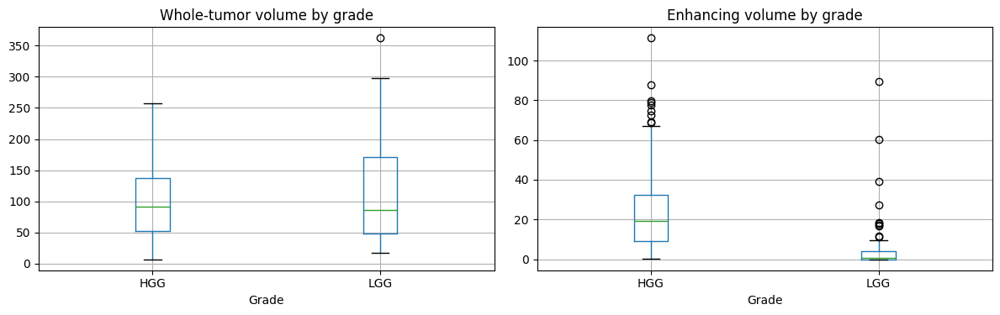

→ HGG tumors are usually larger and enhance more; this motivates the ET/necrosis terms in the risk score.


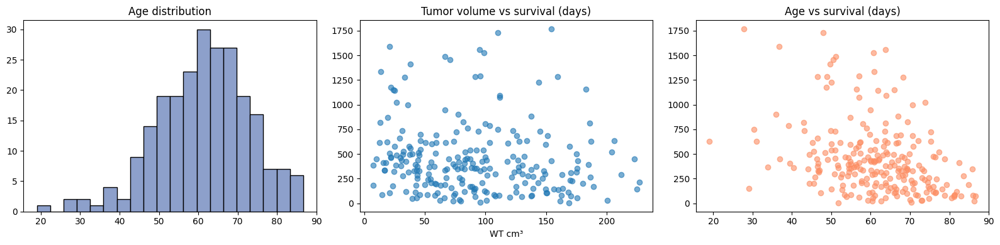

Spearman(WT volume, survival): -0.17


In [6]:
# ---------- 2.3 Metadata: grade (HGG/LGG), age, survival ----------
if meta_name_map is not None and "Grade" in meta_name_map.columns:
    g = meta_name_map[["BraTS_2020_subject_ID", "Grade"]].rename(columns={"BraTS_2020_subject_ID": "id"})
    eda_g = eda.merge(g, on="id", how="left")
    print(eda_g["Grade"].value_counts(dropna=False))
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    eda_g.boxplot(column="wt_cm3", by="Grade", ax=ax[0]); ax[0].set_title("Whole-tumor volume by grade")
    eda_g.boxplot(column="et_cm3", by="Grade", ax=ax[1]); ax[1].set_title("Enhancing volume by grade")
    plt.suptitle(""); plt.tight_layout(); plt.show()
    print("→ HGG tumors are usually larger and enhance more; this motivates the ET/necrosis terms in the risk score.")
else:
    eda_g = eda.copy(); eda_g["Grade"] = "NA"
    print("name_mapping.csv not found — skipping grade analysis.")

if meta_survival is not None:
    sv = meta_survival.copy()
    sv["Survival_days"] = pd.to_numeric(sv["Survival_days"], errors="coerce")
    sv = sv.rename(columns={"Brats20ID": "id"}).merge(eda[["id", "wt_cm3", "et_cm3"]], on="id", how="inner").dropna(subset=["Survival_days"])
    if len(sv) > 5:
        fig, ax = plt.subplots(1, 3, figsize=(16, 4))
        ax[0].hist(sv["Age"], bins=20, color="#8da0cb", edgecolor="k"); ax[0].set_title("Age distribution")
        ax[1].scatter(sv["wt_cm3"], sv["Survival_days"], alpha=0.6); ax[1].set_title("Tumor volume vs survival (days)")
        ax[1].set_xlabel("WT cm³")
        ax[2].scatter(sv["Age"], sv["Survival_days"], alpha=0.6, c="#fc8d62"); ax[2].set_title("Age vs survival (days)")
        plt.tight_layout(); plt.show()
        print("Spearman(WT volume, survival):", round(sv[["wt_cm3", "Survival_days"]].corr(method="spearman").iloc[0, 1], 3))

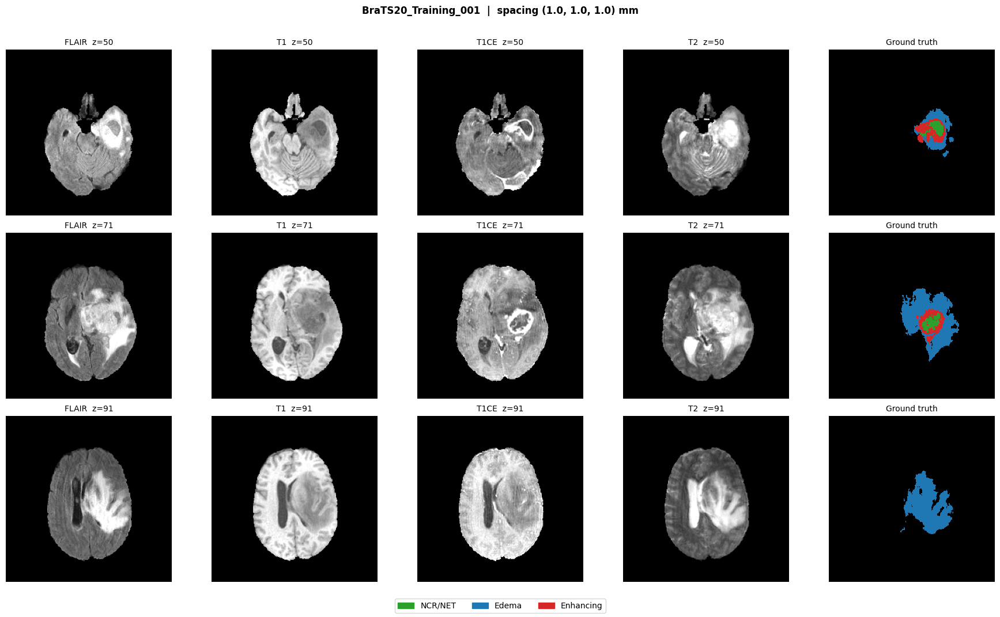

In [7]:
# ---------- 2.4 Look at one patient: 4 modalities + ground truth ----------
def show_patient_modalities(pt, n_slices=3):
    vol, seg, zooms, _ = load_patient_raw(pt["files"])
    zs = np.where((seg > 0).any(axis=(0, 1)))[0]
    picks = np.linspace(zs.min(), zs.max(), n_slices + 2)[1:-1].astype(int) if len(zs) else [vol.shape[3] // 2]
    cols = len(CFG.MODALITIES) + 1
    fig, ax = plt.subplots(len(picks), cols, figsize=(3.6 * cols, 3.6 * len(picks)))
    ax = np.atleast_2d(ax)
    cmap_seg = matplotlib.colors.ListedColormap(["black", "#2ca02c", "#1f77b4", "#d62728"])
    for r, z in enumerate(picks):
        for c, m in enumerate(CFG.MODALITIES):
            ax[r, c].imshow(np.rot90(norm01(vol[c][:, :, z])), cmap="gray")
            ax[r, c].set_title(f"{m.upper()}  z={z}", fontsize=10); ax[r, c].axis("off")
        ax[r, -1].imshow(np.rot90(seg[:, :, z]), cmap=cmap_seg, vmin=0, vmax=3, interpolation="nearest")
        ax[r, -1].set_title("Ground truth", fontsize=10); ax[r, -1].axis("off")
    from matplotlib.patches import Patch
    fig.legend(handles=[Patch(color="#2ca02c", label="NCR/NET"), Patch(color="#1f77b4", label="Edema"),
                        Patch(color="#d62728", label="Enhancing")], loc="lower center", ncol=3)
    plt.suptitle(f"{pt['id']}  |  spacing {zooms} mm", fontweight="bold"); plt.tight_layout(rect=(0, 0.04, 1, 0.97))
    plt.show()


show_patient_modalities(train_patients_all[0])

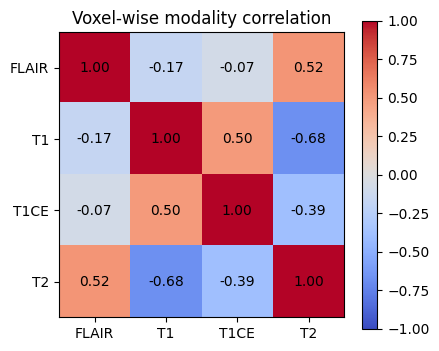


UNDERSTANDING SUMMARY
 • FLAIR  : best for edema (bright)             • T1ce : enhancing tumor (active, blood-brain-barrier breakdown)
 • T2     : edema + tumor                        • T1   : anatomy, necrosis is dark
 • Volumes are 240×240×155 at 1 mm isotropic, already co-registered & skull-stripped.
 • Intensities are NOT comparable between patients  → per-patient z-score on brain voxels.
 • ~85–90 % of brain voxels are background, ET is the rarest class → Dice + BCE loss, tumor-centred patch sampling.
 • Raw label 3 is unused (4 = ET); we remap 4→3 and train on 3 overlapping regions: WT, TC, ET.



In [8]:
# ---------- 2.5 Modality correlation & what each modality shows ----------
def modality_correlation(pt):
    vol, seg, _, _ = load_patient_raw(pt["files"])
    brain = np.any(vol != 0, axis=0)
    flat = np.stack([vol[i][brain] for i in range(4)], 1)
    idx = np.random.choice(len(flat), min(200000, len(flat)), replace=False)
    cm = np.corrcoef(flat[idx].T)
    plt.figure(figsize=(4.6, 4))
    plt.imshow(cm, cmap="coolwarm", vmin=-1, vmax=1)
    plt.xticks(range(4), [m.upper() for m in CFG.MODALITIES]); plt.yticks(range(4), [m.upper() for m in CFG.MODALITIES])
    for i in range(4):
        for j in range(4):
            plt.text(j, i, f"{cm[i, j]:.2f}", ha="center", va="center")
    plt.title("Voxel-wise modality correlation"); plt.colorbar(); plt.show()


modality_correlation(train_patients_all[0])
print("""
UNDERSTANDING SUMMARY
 • FLAIR  : best for edema (bright)             • T1ce : enhancing tumor (active, blood-brain-barrier breakdown)
 • T2     : edema + tumor                        • T1   : anatomy, necrosis is dark
 • Volumes are 240×240×155 at 1 mm isotropic, already co-registered & skull-stripped.
 • Intensities are NOT comparable between patients  → per-patient z-score on brain voxels.
 • ~85–90 % of brain voxels are background, ET is the rarest class → Dice + BCE loss, tumor-centred patch sampling.
 • Raw label 3 is unused (4 = ET); we remap 4→3 and train on 3 overlapping regions: WT, TC, ET.
""")

# PART 3 — Preprocessing
Steps for every patient (identical at training and inference time):
1. Reorient to RAS+ (consistent left/right, front/back, up/down).
2. Crop to the brain bounding box (+ margin) — removes ~60 % empty voxels.
3. Per modality: clip intensities to the 0.5–99.5 percentile **inside the brain**, then z-score
   (mean 0, std 1) using brain voxels only. Background is kept at exactly 0.
4. Labels: 4 → 3, then 3 overlapping binary targets (WT, TC, ET).
5. Cache to disk as float16 `.npy` so training can memory-map random 3D patches quickly.

In [9]:
# ============================================================
# PART 3 — PREPROCESSING + CACHING
# ============================================================
BBOX_MARGIN = 3


def brain_bbox(vol, seg=None, margin=BBOX_MARGIN):
    """Bounding box (tuple of slices) around non-zero voxels (and the tumor if seg is given)."""
    mask = np.any(vol != 0, axis=0)
    if seg is not None:
        mask = mask | (seg > 0)
    if not mask.any():                                   # empty volume -> keep everything
        return tuple(slice(0, s) for s in mask.shape)
    idx = np.argwhere(mask)
    lo, hi = idx.min(0), idx.max(0) + 1
    return tuple(slice(max(int(l) - margin, 0), min(int(h) + margin, int(s)))
                 for l, h, s in zip(lo, hi, mask.shape))


def normalize_volume(vol):
    """vol (4,X,Y,Z) float -> z-scored float32, background = 0."""
    brain = np.any(vol != 0, axis=0)
    out = np.zeros_like(vol, dtype=np.float32)
    for c in range(vol.shape[0]):
        v = vol[c]
        vals = v[brain]
        if vals.size == 0:
            continue
        lo, hi = np.percentile(vals, [0.5, 99.5])
        v = np.clip(v, lo, hi)
        vals = v[brain]
        mu, sd = vals.mean(), vals.std()
        out[c] = np.where(brain, (v - mu) / (sd + 1e-8), 0.0)
    return out


def preprocess_volume(vol, seg=None):
    """Full preprocessing. Returns (img float32 (4,x,y,z), seg_cropped or None, bbox slices)."""
    bb = brain_bbox(vol, seg)
    v = vol[(slice(None),) + bb]
    s = seg[bb] if seg is not None else None
    return normalize_volume(v), s, bb


def cache_paths(pid):
    b = os.path.join(CFG.CACHE_DIR, pid)
    return {"img": b + "_img.npy", "seg": b + "_seg.npy", "fg": b + "_fg.npy",
            "fget": b + "_fget.npy", "meta": b + "_meta.json"}


def build_cache(patients, max_fg=4000):
    """Preprocess every patient once and store it on disk (resumable)."""
    meta_all = {}
    for pt in tqdm(patients, desc="Caching"):
        cp = cache_paths(pt["id"])
        if all(os.path.exists(cp[k]) for k in cp):
            with open(cp["meta"]) as f:
                meta_all[pt["id"]] = json.load(f)
            continue
        vol, seg, zooms, _ = load_patient_raw(pt["files"], with_seg=True)
        img, seg_c, bb = preprocess_volume(vol, seg)
        rng = np.random.default_rng(0)

        def sample(mask):
            idx = np.argwhere(mask)
            if len(idx) > max_fg:
                idx = idx[rng.choice(len(idx), max_fg, replace=False)]
            return idx.astype(np.int16)

        np.save(cp["img"], img.astype(np.float16))
        np.save(cp["seg"], seg_c.astype(np.uint8))
        np.save(cp["fg"], sample(seg_c > 0))
        np.save(cp["fget"], sample(seg_c == 3))
        meta = {"id": pt["id"], "orig_shape": list(vol.shape[1:]), "crop_shape": list(img.shape[1:]),
                "bbox": [[s.start, s.stop] for s in bb], "zooms": list(zooms)}
        with open(cp["meta"], "w") as f:
            json.dump(meta, f)
        meta_all[pt["id"]] = meta
        del vol, seg, img, seg_c
    return meta_all


t0 = time.time()
cache_meta = build_cache(train_patients_all)
print(f"Cached {len(cache_meta)} patients in {time.time() - t0:.0f}s -> {CFG.CACHE_DIR}")
sizes = np.array([m["crop_shape"] for m in cache_meta.values()])
print("Cropped size  min/mean/max per axis:", sizes.min(0), sizes.mean(0).round(0), sizes.max(0))

Caching:   0%|          | 0/369 [00:00<?, ?it/s]

Cached 369 patients in 5220s -> /kaggle/working/cache
Cropped size  min/mean/max per axis: [128 151 104] [144. 176. 142.] [188 199 152]


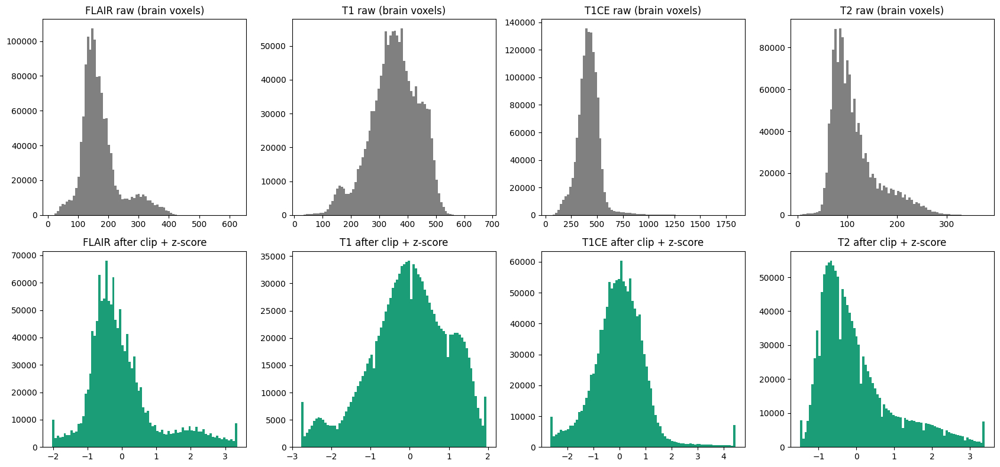

original (240, 240, 155) -> cropped (143, 179, 141)  (kept 40% of voxels)


In [10]:
# ---------- 3.1 Visual check: before / after preprocessing ----------
def show_preprocessing_effect(pt):
    vol, seg, _, _ = load_patient_raw(pt["files"])
    img, seg_c, bb = preprocess_volume(vol, seg)
    brain = np.any(vol != 0, axis=0)
    fig, ax = plt.subplots(2, 4, figsize=(17, 8))
    for c, m in enumerate(CFG.MODALITIES):
        ax[0, c].hist(vol[c][brain], bins=80, color="gray"); ax[0, c].set_title(f"{m.upper()} raw (brain voxels)")
        b = np.any(img != 0, axis=0)
        ax[1, c].hist(img[c][b], bins=80, color="#1b9e77"); ax[1, c].set_title(f"{m.upper()} after clip + z-score")
    plt.tight_layout(); plt.show()
    print(f"original {vol.shape[1:]} -> cropped {img.shape[1:]}  "
          f"(kept {100 * np.prod(img.shape[1:]) / np.prod(vol.shape[1:]):.0f}% of voxels)")


show_preprocessing_effect(train_patients_all[0])

# PART 4 — Split, Patch Dataset, Augmentation
* Patient-level split (never mix slices of one patient across sets), stratified by HGG/LGG when known.
* We train on random **3D patches** (default 128³): 67 % are centred around tumor voxels (half of those
  around enhancing tumor, the rarest class), 33 % are random → handles class imbalance.
* Augmentations: random flips, 90° in-plane rotations, per-channel intensity scale/shift, Gaussian noise.

In [11]:
# ============================================================
# PART 4 — SPLIT
# ============================================================
from sklearn.model_selection import train_test_split

ids_all = [p["id"] for p in train_patients_all]
grade_map = {}
if meta_name_map is not None and "Grade" in meta_name_map.columns:
    grade_map = dict(zip(meta_name_map["BraTS_2020_subject_ID"], meta_name_map["Grade"]))
strat = [grade_map.get(i, "NA") for i in ids_all]
if len(set(strat)) < 2 or min(pd.Series(strat).value_counts()) < 3:
    strat = None

n_total = len(ids_all)
n_test = max(1, int(round(CFG.SPLIT[2] * n_total)))
n_val = max(1, int(round(CFG.SPLIT[1] * n_total)))
ids_trainval, ids_test = train_test_split(ids_all, test_size=n_test, random_state=CFG.SEED, stratify=strat)
strat_tv = [grade_map.get(i, "NA") for i in ids_trainval] if strat else None
ids_train, ids_val = train_test_split(ids_trainval, test_size=n_val, random_state=CFG.SEED, stratify=strat_tv)

split = {"train": ids_train, "val": ids_val, "test": ids_test}
with open(os.path.join(CFG.OUT_DIR, "split.json"), "w") as f:
    json.dump(split, f, indent=1)
print({k: len(v) for k, v in split.items()})
pid2patient = {p["id"]: p for p in train_patients_all}

{'train': 295, 'val': 37, 'test': 37}


batch: (2, 4, 128, 128, 128) (2, 3, 128, 128, 128) | fg ratio per region (WT,TC,ET): [0.0672, 0.02, 0.0168]


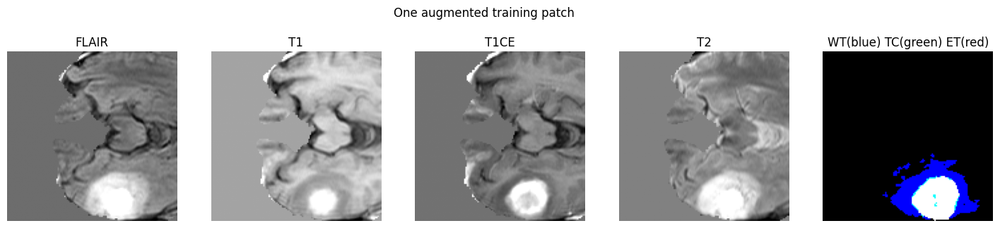

In [12]:
# ============================================================
# PART 4b — PATCH DATASET + AUGMENTATION
# ============================================================
def augment_patch(img, reg, rng):
    """img (4,x,y,z) float32, reg (3,x,y,z) uint8 -> augmented copies."""
    for ax in (1, 2, 3):                                       # flips
        if rng.random() < 0.5:
            img = np.flip(img, ax); reg = np.flip(reg, ax)
    if rng.random() < 0.5:                                      # in-plane 90° rotation
        k = int(rng.integers(1, 4))
        img = np.rot90(img, k, axes=(1, 2)); reg = np.rot90(reg, k, axes=(1, 2))
    img = np.ascontiguousarray(img); reg = np.ascontiguousarray(reg)
    mask = img != 0
    if rng.random() < 0.8:                                      # intensity scale / shift per channel
        for c in range(img.shape[0]):
            img[c] = img[c] * rng.uniform(0.9, 1.1) + rng.uniform(-0.1, 0.1)
    if rng.random() < 0.25:                                     # gaussian noise
        img = img + rng.normal(0, rng.uniform(0.0, 0.05), img.shape).astype(np.float32)
    return img * mask, reg


def crop_with_pad(arr, start, patch):
    """arr (..., X, Y, Z) memmap/ndarray -> patch (..., px, py, pz), zero-padded at the end."""
    sl, pads = [], []
    for a in range(3):
        S = arr.shape[-3 + a]
        s0 = int(start[a]); s1 = min(s0 + patch[a], S)
        sl.append(slice(s0, s1)); pads.append(patch[a] - (s1 - s0))
    out = np.asarray(arr[(Ellipsis,) + tuple(sl)])
    if any(pads):
        out = np.pad(out, [(0, 0)] * (out.ndim - 3) + [(0, p) for p in pads])
    return out


class BraTSPatchDataset(Dataset):
    def __init__(self, ids, length, patch=CFG.PATCH, fg_prob=CFG.FG_PROB, augment=True):
        self.ids, self.length, self.patch = list(ids), int(length), tuple(patch)
        self.fg_prob, self.augment = fg_prob, augment
        self._fg = {}

    def __len__(self):
        return self.length

    def _fg_coords(self, pid):
        if pid not in self._fg:
            cp = cache_paths(pid)
            self._fg[pid] = (np.load(cp["fg"]), np.load(cp["fget"]))
        return self._fg[pid]

    def __getitem__(self, i):
        rng = np.random.default_rng()                           # fresh entropy -> safe with workers
        pid = self.ids[int(rng.integers(len(self.ids)))]
        cp = cache_paths(pid)
        img = np.load(cp["img"], mmap_mode="r")
        seg = np.load(cp["seg"], mmap_mode="r")
        shape = img.shape[1:]
        p = self.patch

        fg, fget = self._fg_coords(pid)
        use_fg = rng.random() < self.fg_prob and len(fg) > 0
        if use_fg:
            pool = fget if (len(fget) > 0 and rng.random() < 0.5) else fg
            c = pool[int(rng.integers(len(pool)))].astype(int)
            start = [c[a] - int(rng.integers(int(0.25 * p[a]), int(0.75 * p[a]) + 1)) for a in range(3)]
        else:
            start = [int(rng.integers(0, max(shape[a] - p[a], 0) + 1)) for a in range(3)]
        start = [int(np.clip(start[a], 0, max(shape[a] - p[a], 0))) for a in range(3)]

        x = crop_with_pad(img, start, p).astype(np.float32)
        y = seg_to_regions(crop_with_pad(seg, start, p))
        if self.augment:
            x, y = augment_patch(x, y, rng)
        return torch.from_numpy(np.ascontiguousarray(x)), torch.from_numpy(np.ascontiguousarray(y)).float()


train_ds = BraTSPatchDataset(ids_train, CFG.ITERS_PER_EPOCH * CFG.BATCH_SIZE, augment=True)
train_loader = DataLoader(train_ds, batch_size=CFG.BATCH_SIZE, shuffle=False, num_workers=CFG.NUM_WORKERS,
                          pin_memory=(DEVICE.type == "cuda"), drop_last=True,
                          persistent_workers=(CFG.NUM_WORKERS > 0))

xb, yb = next(iter(train_loader))
print("batch:", tuple(xb.shape), tuple(yb.shape), "| fg ratio per region (WT,TC,ET):",
      [round(float(yb[:, i].mean()), 4) for i in range(3)])


def show_batch_sample(x, y):
    z = int(y[0, 0].sum(dim=(0, 1)).argmax()) if y[0, 0].sum() > 0 else x.shape[-1] // 2
    fig, ax = plt.subplots(1, 5, figsize=(18, 3.8))
    for c in range(4):
        ax[c].imshow(x[0, c, :, :, z].numpy().T, cmap="gray", origin="lower")
        ax[c].set_title(CFG.MODALITIES[c].upper())
    rgb = np.zeros(y.shape[2:4] + (3,)); wt, tc, et = [y[0, i, :, :, z].numpy() for i in range(3)]
    rgb[..., 2] = wt; rgb[..., 1] = tc; rgb[..., 0] = et
    ax[4].imshow(np.transpose(rgb, (1, 0, 2)), origin="lower"); ax[4].set_title("WT(blue) TC(green) ET(red)")
    for a in ax:
        a.axis("off")
    plt.suptitle("One augmented training patch"); plt.show()


show_batch_sample(xb, yb)

# PART 5 — Model: 3D Residual Attention U-Net
* 5 resolution levels, residual conv blocks with **GroupNorm** (works with batch size 1–2).
* **Attention gates** on every skip connection (focus on tumor, suppress healthy tissue).
* **Deep supervision**: auxiliary outputs at two decoder depths during training.
* Output = 3 sigmoid channels (WT, TC, ET) — the standard BraTS region formulation.

In [13]:
# ============================================================
# PART 5 — MODEL
# ============================================================
def GN(c):
    return nn.GroupNorm(num_groups=min(8, c), num_channels=c)


class ConvBlock(nn.Module):
    """(Conv3x3x3 - GN - LeakyReLU) x2 with a residual connection."""
    def __init__(self, cin, cout):
        super().__init__()
        self.c1 = nn.Conv3d(cin, cout, 3, padding=1, bias=False); self.n1 = GN(cout)
        self.c2 = nn.Conv3d(cout, cout, 3, padding=1, bias=False); self.n2 = GN(cout)
        self.skip = nn.Conv3d(cin, cout, 1, bias=False) if cin != cout else nn.Identity()
        self.act = nn.LeakyReLU(0.01)

    def forward(self, x):
        y = self.act(self.n1(self.c1(x)))
        y = self.n2(self.c2(y))
        return self.act(y + self.skip(x))


class AttentionGate(nn.Module):
    """Additive attention gate (Oktay et al.). g = decoder signal, x = encoder skip (same resolution)."""
    def __init__(self, ch):
        super().__init__()
        inter = max(ch // 2, 8)
        self.wg = nn.Sequential(nn.Conv3d(ch, inter, 1, bias=False), GN(inter))
        self.wx = nn.Sequential(nn.Conv3d(ch, inter, 1, bias=False), GN(inter))
        self.psi = nn.Sequential(nn.Conv3d(inter, 1, 1), nn.Sigmoid())
        self.act = nn.LeakyReLU(0.01)

    def forward(self, g, x):
        return x * self.psi(self.act(self.wg(g) + self.wx(x)))


class ResAttUNet3D(nn.Module):
    def __init__(self, in_ch=4, out_ch=3, base=16, deep_supervision=True, dropout=0.1):
        super().__init__()
        f = [base * m for m in (1, 2, 4, 8, 16)]
        self.f, self.deep = f, deep_supervision
        self.enc = nn.ModuleList([ConvBlock(in_ch, f[0])] + [ConvBlock(f[i - 1], f[i]) for i in range(1, 5)])
        self.down = nn.ModuleList([
            nn.Sequential(nn.Conv3d(f[i], f[i], 3, stride=2, padding=1, bias=False), GN(f[i]), nn.LeakyReLU(0.01))
            for i in range(4)])
        self.drop = nn.Dropout3d(dropout)
        self.up = nn.ModuleList([nn.ConvTranspose3d(f[i + 1], f[i], 2, stride=2) for i in range(4)])
        self.att = nn.ModuleList([AttentionGate(f[i]) for i in range(4)])
        self.dec = nn.ModuleList([ConvBlock(2 * f[i], f[i]) for i in range(4)])
        self.head = nn.Conv3d(f[0], out_ch, 1)
        self.aux1 = nn.Conv3d(f[1], out_ch, 1)
        self.aux2 = nn.Conv3d(f[2], out_ch, 1)
        for m in self.modules():
            if isinstance(m, (nn.Conv3d, nn.ConvTranspose3d)):
                nn.init.kaiming_normal_(m.weight, a=0.01, nonlinearity="leaky_relu")
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def forward(self, x):
        skips = []
        for i in range(4):
            x = self.enc[i](x)
            skips.append(x)
            x = self.down[i](x)
        x = self.drop(self.enc[4](x))
        outs = {}
        for i in (3, 2, 1, 0):
            u = self.up[i](x)
            s = self.att[i](u, skips[i])
            x = self.dec[i](torch.cat([u, s], 1))
            outs[i] = x
        main = self.head(outs[0])
        if self.training and self.deep:
            return [main, self.aux1(outs[1]), self.aux2(outs[2])]
        return main


def build_model():
    return ResAttUNet3D(in_ch=len(CFG.MODALITIES), out_ch=3, base=CFG.BASE_FILTERS).to(DEVICE)


_m = build_model()
print(f"Parameters: {sum(p.numel() for p in _m.parameters()) / 1e6:.2f} M")
with torch.no_grad():
    _m.train(); _o = _m(torch.zeros(1, 4, *CFG.PATCH, device=DEVICE))
    print("train outputs:", [tuple(o.shape) for o in _o])
    _m.eval(); print("eval output  :", tuple(_m(torch.zeros(1, 4, *CFG.PATCH, device=DEVICE)).shape))
del _m, _o
if DEVICE.type == "cuda":
    torch.cuda.empty_cache()

Parameters: 6.35 M
train outputs: [(1, 3, 128, 128, 128), (1, 3, 64, 64, 64), (1, 3, 32, 32, 32)]
eval output  : (1, 3, 128, 128, 128)


# PART 6 — Loss, Metrics, Sliding-Window Inference

In [15]:
# ============================================================
# PART 6 — LOSS
# ============================================================
def soft_dice_loss(logits, target, eps=1e-5):
    p = torch.sigmoid(logits)
    dims = (0, 2, 3, 4)
    inter = (p * target).sum(dims)
    den = p.sum(dims) + target.sum(dims)
    return 1.0 - ((2 * inter + eps) / (den + eps)).mean()


def seg_loss(logits, target):
    return soft_dice_loss(logits, target) + F.binary_cross_entropy_with_logits(logits, target)


def total_loss(outputs, target, weights=(1.0, 0.5, 0.25)):
    if not isinstance(outputs, (list, tuple)):
        return seg_loss(outputs, target)
    loss = 0.0
    for w, o in zip(weights, outputs):
        if o.shape[2:] != target.shape[2:]:
            o = F.interpolate(o, size=target.shape[2:], mode="trilinear", align_corners=False)
        loss = loss + w * seg_loss(o, target)
    return loss / sum(weights[:len(outputs)])

In [16]:
# ============================================================
# PART 6b — METRICS (Dice, IoU, sensitivity, precision, HD95)
# ============================================================
HD_MAX = 373.13          # BraTS convention for undefined HD95


def dice_np(p, g):
    s = p.sum() + g.sum()
    return 1.0 if s == 0 else float(2.0 * (p & g).sum() / s)


def iou_np(p, g):
    u = (p | g).sum()
    return 1.0 if u == 0 else float((p & g).sum() / u)


def sens_np(p, g):
    return 1.0 if g.sum() == 0 else float((p & g).sum() / g.sum())


def prec_np(p, g):
    return (1.0 if g.sum() == 0 else 0.0) if p.sum() == 0 else float((p & g).sum() / p.sum())


def surface(mask):
    return mask & ~ndi.binary_erosion(mask, border_value=0)


def hd95_np(p, g, spacing=(1.0, 1.0, 1.0)):
    if p.sum() == 0 and g.sum() == 0:
        return 0.0
    if p.sum() == 0 or g.sum() == 0:
        return HD_MAX
    sp, sg = surface(p), surface(g)
    d_to_g = ndi.distance_transform_edt(~sg, sampling=spacing)
    d_to_p = ndi.distance_transform_edt(~sp, sampling=spacing)
    return float(np.percentile(np.concatenate([d_to_g[sp], d_to_p[sg]]), 95))


def region_metrics(pred, gt, spacing=(1.0, 1.0, 1.0), hd=True):
    """pred, gt: (3,X,Y,Z) bool (WT,TC,ET) -> flat dict."""
    r = {}
    for i, name in enumerate(REGIONS):
        p, g = pred[i].astype(bool), gt[i].astype(bool)
        r[f"Dice_{name}"] = dice_np(p, g); r[f"IoU_{name}"] = iou_np(p, g)
        r[f"Sens_{name}"] = sens_np(p, g); r[f"Prec_{name}"] = prec_np(p, g)
        if hd:
            r[f"HD95_{name}"] = hd95_np(p, g, spacing)
    r["Dice_mean"] = float(np.mean([r[f"Dice_{n}"] for n in REGIONS]))
    return r

In [17]:
# ============================================================
# PART 6c — SLIDING-WINDOW INFERENCE + POST-PROCESSING
# ============================================================
def gaussian_window(patch, sigma_scale=0.125):
    g = np.ones(patch, np.float32)
    for a, p in enumerate(patch):
        c = np.arange(p, dtype=np.float32) - (p - 1) / 2.0
        w = np.exp(-0.5 * (c / (sigma_scale * p)) ** 2)
        shape = [1, 1, 1]; shape[a] = p
        g = g * w.reshape(shape)
    g = g / g.max()
    return np.clip(g, 1e-3, None).astype(np.float32)


def _starts(S, p, overlap):
    if S <= p:
        return [0]
    step = max(int(p * (1 - overlap)), 1)
    st = list(range(0, S - p + 1, step))
    if st[-1] != S - p:
        st.append(S - p)
    return st


@torch.no_grad()
def sliding_window_predict(model, img, patch=None, overlap=0.5, tta=False, sw_batch=2):
    """img: (4,X,Y,Z) float array (already preprocessed). Returns probabilities (3,X,Y,Z) float32."""
    patch = tuple(patch or CFG.PATCH)          # read at call time (load_model may change it)
    model.eval()
    X = torch.from_numpy(np.ascontiguousarray(img, dtype=np.float32))
    S0 = tuple(X.shape[1:])
    pad = [max(patch[a] - S0[a], 0) for a in range(3)]
    if any(pad):
        X = F.pad(X, (0, pad[2], 0, pad[1], 0, pad[0]))
    S = tuple(X.shape[1:])
    gw = torch.from_numpy(gaussian_window(patch)).to(DEVICE)
    acc = torch.zeros((3,) + S, device=DEVICE)
    wacc = torch.zeros(S, device=DEVICE)
    coords = [(a, b, c) for a in _starts(S[0], patch[0], overlap)
              for b in _starts(S[1], patch[1], overlap) for c in _starts(S[2], patch[2], overlap)]
    flips = [[], [2], [3], [4]] if tta else [[]]
    use_amp = CFG.AMP and DEVICE.type == "cuda"

    for i in range(0, len(coords), sw_batch):
        cs = coords[i:i + sw_batch]
        xb = torch.stack([X[:, a:a + patch[0], b:b + patch[1], c:c + patch[2]] for a, b, c in cs]).to(DEVICE)
        pr = 0
        for fl in flips:
            xin = torch.flip(xb, fl) if fl else xb
            with torch.autocast(device_type=DEVICE.type, enabled=use_amp):
                lg = model(xin)
            p = torch.sigmoid(lg.float())
            pr = pr + (torch.flip(p, fl) if fl else p)
        pr = pr / len(flips)
        for k, (a, b, c) in enumerate(cs):
            acc[:, a:a + patch[0], b:b + patch[1], c:c + patch[2]] += pr[k] * gw
            wacc[a:a + patch[0], b:b + patch[1], c:c + patch[2]] += gw
    prob = (acc / wacc.clamp_min(1e-6))[:, :S0[0], :S0[1], :S0[2]]
    return prob.cpu().numpy()


def remove_small(mask, min_voxels):
    if min_voxels <= 0 or not mask.any():
        return mask
    lab, n = ndi.label(mask)
    if n == 0:
        return mask
    sizes = ndi.sum(mask, lab, index=np.arange(1, n + 1))
    keep = np.zeros(n + 1, bool); keep[1:] = sizes >= min_voxels
    return keep[lab]


def postprocess(prob, thr=0.5, min_wt=200, min_et=50):
    """prob (3,X,Y,Z) -> bool (3,X,Y,Z) with consistent hierarchy ET ⊂ TC ⊂ WT."""
    wt, tc, et = prob[0] > thr, prob[1] > thr, prob[2] > thr
    tc = tc | et
    wt = wt | tc
    wt = remove_small(wt, min_wt)
    tc &= wt
    et &= tc
    if et.sum() < min_et:
        et[:] = False                       # tiny enhancing blobs are treated as noise (stay inside TC)
    return np.stack([wt, tc, et], 0)


def load_cached(pid):
    cp = cache_paths(pid)
    with open(cp["meta"]) as f:
        meta = json.load(f)
    return np.load(cp["img"]).astype(np.float32), np.load(cp["seg"]), meta


def evaluate_ids(model, ids, overlap=0.25, tta=False, hd=False, desc="eval"):
    rows = []
    for pid in tqdm(ids, desc=desc, leave=False):
        img, seg, meta = load_cached(pid)
        prob = sliding_window_predict(model, img, overlap=overlap, tta=tta)
        pred = postprocess(prob)
        r = region_metrics(pred, seg_to_regions(seg).astype(bool), tuple(meta["zooms"]), hd=hd)
        r["id"] = pid
        rows.append(r)
    return pd.DataFrame(rows)

# PART 7 — Training
AdamW + linear warm-up + cosine decay, mixed precision (AMP), gradient clipping, deep supervision,
periodic sliding-window validation, best-checkpoint saving, early stopping, **resumable** (re-run the cell to continue).

Epoch 1/100:   0%|          | 0/200 [00:00<?, ?it/s]

Ep   1 | loss 1.3633 | 129s


Epoch 2/100:   0%|          | 0/200 [00:00<?, ?it/s]

Ep   2 | loss 0.5184 | 125s


Epoch 3/100:   0%|          | 0/200 [00:00<?, ?it/s]

...

Epoch 99/100:   0%|          | 0/200 [00:00<?, ?it/s]

Ep  99 | loss 0.1231 | 124s


Epoch 100/100:   0%|          | 0/200 [00:00<?, ?it/s]

val:   0%|          | 0/12 [00:00<?, ?it/s]

Ep 100 | loss 0.1181 | 124s | val Dice WT 0.908 TC 0.842 ET 0.754 mean 0.835  ⭐ best


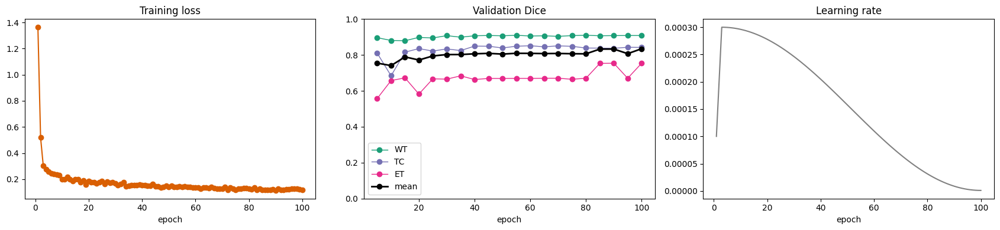

In [18]:
# ============================================================
# PART 7 — TRAINING LOOP
# ============================================================
def make_scaler(enabled):
    try:
        return torch.amp.GradScaler("cuda", enabled=enabled)
    except Exception:
        return torch.cuda.amp.GradScaler(enabled=enabled)


def lr_at(step, total, warm, base_lr):
    if step < warm:
        return base_lr * (step + 1) / max(warm, 1)
    t = (step - warm) / max(total - warm, 1)
    return 1e-6 + 0.5 * (base_lr - 1e-6) * (1 + math.cos(math.pi * t))


CKPT_BEST = os.path.join(CFG.CKPT_DIR, "best.pt")
CKPT_LAST = os.path.join(CFG.CKPT_DIR, "last.pt")


def save_ckpt(path, model, opt, scaler, epoch, history, best, bad):
    torch.save({"model": model.state_dict(), "opt": opt.state_dict(), "scaler": scaler.state_dict(),
                "epoch": epoch, "history": history, "best": best, "bad": bad,
                "base": CFG.BASE_FILTERS, "patch": CFG.PATCH, "modalities": CFG.MODALITIES}, path)


def train(resume=True):
    model = build_model()
    opt = torch.optim.AdamW(model.parameters(), lr=CFG.LR, weight_decay=CFG.WEIGHT_DECAY)
    use_amp = CFG.AMP and DEVICE.type == "cuda"
    scaler = make_scaler(use_amp)
    history, best, bad, start = [], -1.0, 0, 0
    if resume and os.path.exists(CKPT_LAST):
        ck = torch.load(CKPT_LAST, map_location=DEVICE, weights_only=False)
        model.load_state_dict(ck["model"]); opt.load_state_dict(ck["opt"]); scaler.load_state_dict(ck["scaler"])
        history, best, bad, start = ck["history"], ck["best"], ck["bad"], ck["epoch"] + 1
        print(f"Resumed from epoch {start} (best val Dice {best:.4f})")

    steps_per_epoch = len(train_loader)
    total, warm = CFG.EPOCHS * steps_per_epoch, CFG.WARMUP_EPOCHS * steps_per_epoch
    val_ids = ids_val[:CFG.VAL_MAX_PATIENTS]

    for epoch in range(start, CFG.EPOCHS):
        model.train(); t0 = time.time(); losses = []
        pbar = tqdm(train_loader, desc=f"Epoch {epoch + 1}/{CFG.EPOCHS}", leave=False)
        for it, (x, y) in enumerate(pbar):
            lr = lr_at(epoch * steps_per_epoch + it, total, warm, CFG.LR)
            for g in opt.param_groups:
                g["lr"] = lr
            x, y = x.to(DEVICE, non_blocking=True), y.to(DEVICE, non_blocking=True)
            opt.zero_grad(set_to_none=True)
            with torch.autocast(device_type=DEVICE.type, enabled=use_amp):
                out = model(x)
            loss = total_loss([o.float() for o in out], y)
            scaler.scale(loss).backward()
            scaler.unscale_(opt)
            nn.utils.clip_grad_norm_(model.parameters(), CFG.GRAD_CLIP)
            scaler.step(opt); scaler.update()
            losses.append(loss.item())
            if hasattr(pbar, "set_postfix"):
                pbar.set_postfix(loss=f"{np.mean(losses):.4f}", lr=f"{lr:.1e}")

        rec = {"epoch": epoch + 1, "train_loss": float(np.mean(losses)), "lr": lr, "time_s": time.time() - t0}
        do_val = ((epoch + 1) % CFG.VAL_EVERY == 0) or (epoch + 1 == CFG.EPOCHS)
        if do_val:
            vdf = evaluate_ids(model, val_ids, overlap=CFG.SW_OVERLAP_VAL, tta=False, hd=False, desc="val")
            for k in ("Dice_WT", "Dice_TC", "Dice_ET", "Dice_mean"):
                rec["val_" + k] = float(vdf[k].mean())
            if rec["val_Dice_mean"] > best:
                best, bad = rec["val_Dice_mean"], 0
                save_ckpt(CKPT_BEST, model, opt, scaler, epoch, history + [rec], best, bad)
                rec["saved_best"] = True
            else:
                bad += 1
        history.append(rec)
        save_ckpt(CKPT_LAST, model, opt, scaler, epoch, history, best, bad)
        msg = f"Ep {epoch + 1:3d} | loss {rec['train_loss']:.4f} | {rec['time_s']:.0f}s"
        if do_val:
            msg += (f" | val Dice WT {rec['val_Dice_WT']:.3f} TC {rec['val_Dice_TC']:.3f} "
                    f"ET {rec['val_Dice_ET']:.3f} mean {rec['val_Dice_mean']:.3f}"
                    + ("  ⭐ best" if rec.get("saved_best") else ""))
        print(msg)
        if do_val and bad >= CFG.EARLY_STOP_PATIENCE:
            print(f"Early stopping (no improvement for {bad} validation rounds)")
            break
    pd.DataFrame(history).to_csv(os.path.join(CFG.OUT_DIR, "training_history.csv"), index=False)
    return model, history


def plot_history(history):
    h = pd.DataFrame(history)
    fig, ax = plt.subplots(1, 3, figsize=(17, 4))
    ax[0].plot(h["epoch"], h["train_loss"], "o-", color="#d95f02"); ax[0].set_title("Training loss"); ax[0].set_xlabel("epoch")
    if "val_Dice_mean" in h:
        v = h.dropna(subset=["val_Dice_mean"])
        for n, c in zip(["WT", "TC", "ET", "mean"], ["#1b9e77", "#7570b3", "#e7298a", "k"]):
            ax[1].plot(v["epoch"], v[f"val_Dice_{n}"], "o-", label=n, color=c, lw=2 if n == "mean" else 1)
        ax[1].set_title("Validation Dice"); ax[1].legend(); ax[1].set_xlabel("epoch"); ax[1].set_ylim(0, 1)
    ax[2].plot(h["epoch"], h["lr"], color="gray"); ax[2].set_title("Learning rate"); ax[2].set_xlabel("epoch")
    plt.tight_layout(); plt.savefig(os.path.join(CFG.OUT_DIR, "training_curves.png"), dpi=130); plt.show()


def load_model(path=None):
    path = path or (CKPT_BEST if os.path.exists(CKPT_BEST) else CKPT_LAST)
    ck = torch.load(path, map_location=DEVICE, weights_only=False)
    m = ResAttUNet3D(in_ch=len(ck.get("modalities", CFG.MODALITIES)), out_ch=3, base=ck["base"]).to(DEVICE)
    m.load_state_dict(ck["model"]); m.eval()
    CFG.PATCH = tuple(ck["patch"])
    print(f"Loaded {path} (epoch {ck['epoch'] + 1}, val Dice {ck['best']:.4f})")
    return m


model, history = train(resume=True)
plot_history(history)

# PART 8 — Evaluation on the held-out test patients
Full sliding-window inference (50 % overlap, flip TTA), post-processing, then Dice / IoU /
sensitivity / precision / **HD95 (mm)** per region, a voxel-wise confusion matrix, volume agreement
and best / worst cases.

In [19]:
# ============================================================
# PART 8 — TEST EVALUATION
# ============================================================
model = load_model()


def to_label_map(reg):
    lab = np.zeros(reg.shape[1:], np.uint8)
    lab[reg[0]] = 2; lab[reg[1]] = 1; lab[reg[2]] = 3
    return lab


def evaluate_test(model, ids):
    rows, preds = [], {}
    for pid in tqdm(ids, desc="test"):
        img, seg, meta = load_cached(pid)
        prob = sliding_window_predict(model, img, overlap=CFG.SW_OVERLAP_TEST, tta=CFG.TTA)
        pred = postprocess(prob)
        gt = seg_to_regions(seg).astype(bool)
        r = region_metrics(pred, gt, tuple(meta["zooms"]), hd=True)
        vox = float(np.prod(meta["zooms"])) / 1000.0
        r.update({"id": pid, "gt_wt_cm3": gt[0].sum() * vox, "pred_wt_cm3": pred[0].sum() * vox,
                  "gt_et_cm3": gt[2].sum() * vox, "pred_et_cm3": pred[2].sum() * vox})
        rows.append(r); preds[pid] = to_label_map(pred)
    return pd.DataFrame(rows), preds


test_df, test_preds = evaluate_test(model, ids_test)
test_df.to_csv(os.path.join(CFG.OUT_DIR, "test_metrics_per_patient.csv"), index=False)

cols = [f"{m}_{r}" for m in ("Dice", "IoU", "Sens", "Prec", "HD95") for r in REGIONS] + ["Dice_mean"]
summary = test_df[cols].agg(["mean", "std", "median", "min", "max"]).T.round(4)
summary.to_csv(os.path.join(CFG.OUT_DIR, "test_metrics_summary.csv"))
print(f"TEST RESULTS on {len(test_df)} unseen patients")
print(summary)

Loaded /kaggle/working/checkpoints/best.pt (epoch 100, val Dice 0.8347)


test:   0%|          | 0/37 [00:00<?, ?it/s]

TEST RESULTS on 37 unseen patients
              mean      std  median     min       max
Dice_WT     0.9234   0.0526  0.9405  0.7733    0.9765
Dice_TC     0.8660   0.1913  0.9368  0.0766    0.9772
Dice_ET     0.7955   0.2441  0.8876  0.0000    1.0000
IoU_WT      0.8616   0.0844  0.8876  0.6304    0.9540
IoU_TC      0.7983   0.2144  0.8811  0.0398    0.9555
IoU_ET      0.7093   0.2520  0.7980  0.0000    1.0000
Sens_WT     0.9195   0.0636  0.9425  0.7526    0.9901
Sens_TC     0.8816   0.1830  0.9440  0.1972    0.9925
Sens_ET     0.8647   0.2067  0.9201  0.0000    1.0000
Prec_WT     0.9305   0.0630  0.9479  0.6689    0.9969
Prec_TC     0.9013   0.1598  0.9500  0.0399    0.9999
Prec_ET     0.7981   0.2581  0.8991  0.0000    1.0000
HD95_WT     3.6006   3.0861  2.2361  1.0000   12.1655
HD95_TC     3.8506   4.8168  1.7321  1.0000   21.6564
HD95_ET    22.5646  85.0194  1.4142  0.0000  373.1300
Dice_mean   0.8616   0.1162  0.9148  0.6084    0.9709


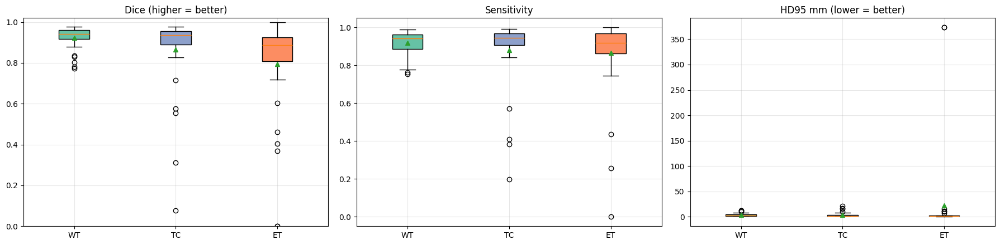

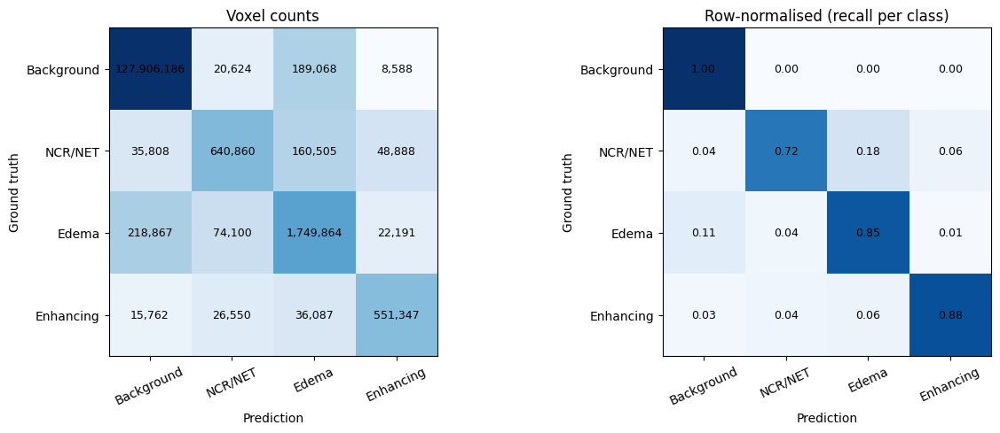

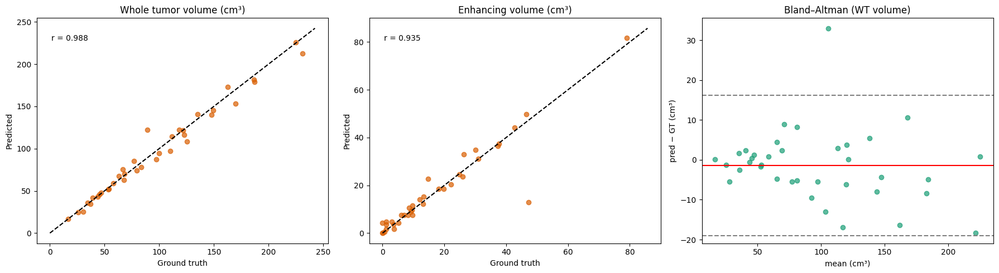

In [20]:
# ---------- 8.1 Metric distributions ----------
fig, ax = plt.subplots(1, 3, figsize=(18, 4.5))
for a, metric, ttl in zip(ax, ["Dice", "Sens", "HD95"], ["Dice (higher = better)", "Sensitivity", "HD95 mm (lower = better)"]):
    data = [test_df[f"{metric}_{r}"] for r in REGIONS]
    bp = a.boxplot(data, patch_artist=True, showmeans=True); a.set_xticklabels(REGIONS)
    for patch_, c in zip(bp["boxes"], ["#66c2a5", "#8da0cb", "#fc8d62"]):
        patch_.set_facecolor(c)
    a.set_title(ttl); a.grid(alpha=0.3)
ax[0].set_ylim(0, 1.02)
plt.tight_layout(); plt.savefig(os.path.join(CFG.OUT_DIR, "test_metric_boxplots.png"), dpi=130); plt.show()

# ---------- 8.2 Confusion matrix (voxel-wise, 4 classes) ----------
cm = np.zeros((4, 4), np.int64)
for pid, pl in test_preds.items():
    gt = np.load(cache_paths(pid)["seg"])
    cm += np.bincount((gt.astype(np.int64) * 4 + pl.astype(np.int64)).ravel(), minlength=16).reshape(4, 4)
cmn = cm / cm.sum(1, keepdims=True).clip(1)
names = ["Background", "NCR/NET", "Edema", "Enhancing"]
fig, ax = plt.subplots(1, 2, figsize=(13, 5))
for a, M, t, fmt in zip(ax, [cm, cmn], ["Voxel counts", "Row-normalised (recall per class)"], ["{:,}", "{:.2f}"]):
    a.imshow(M if M is cmn else np.log10(M + 1), cmap="Blues")
    a.set_xticks(range(4)); a.set_xticklabels(names, rotation=25); a.set_yticks(range(4)); a.set_yticklabels(names)
    a.set_xlabel("Prediction"); a.set_ylabel("Ground truth"); a.set_title(t)
    for i in range(4):
        for j in range(4):
            a.text(j, i, fmt.format(M[i, j]), ha="center", va="center", color="black", fontsize=9)
plt.tight_layout(); plt.savefig(os.path.join(CFG.OUT_DIR, "test_confusion_matrix.png"), dpi=130); plt.show()

# ---------- 8.3 Volume agreement ----------
fig, ax = plt.subplots(1, 3, figsize=(18, 5))
for a, (g, p, t) in zip(ax[:2], [("gt_wt_cm3", "pred_wt_cm3", "Whole tumor volume (cm³)"),
                                 ("gt_et_cm3", "pred_et_cm3", "Enhancing volume (cm³)")]):
    a.scatter(test_df[g], test_df[p], alpha=0.7, c="#d95f02")
    mx = max(test_df[g].max(), test_df[p].max()) * 1.05 + 1e-6
    a.plot([0, mx], [0, mx], "k--"); a.set_xlabel("Ground truth"); a.set_ylabel("Predicted"); a.set_title(t)
    if len(test_df) > 2:
        a.text(0.05, 0.9, f"r = {np.corrcoef(test_df[g], test_df[p])[0, 1]:.3f}", transform=a.transAxes)
mean_v = (test_df["gt_wt_cm3"] + test_df["pred_wt_cm3"]) / 2
diff_v = test_df["pred_wt_cm3"] - test_df["gt_wt_cm3"]
ax[2].scatter(mean_v, diff_v, alpha=0.7, c="#1b9e77")
ax[2].axhline(diff_v.mean(), color="r"); ax[2].axhline(diff_v.mean() + 1.96 * diff_v.std(), color="gray", ls="--")
ax[2].axhline(diff_v.mean() - 1.96 * diff_v.std(), color="gray", ls="--")
ax[2].set_title("Bland–Altman (WT volume)"); ax[2].set_xlabel("mean (cm³)"); ax[2].set_ylabel("pred − GT (cm³)")
plt.tight_layout(); plt.savefig(os.path.join(CFG.OUT_DIR, "test_volume_agreement.png"), dpi=130); plt.show()

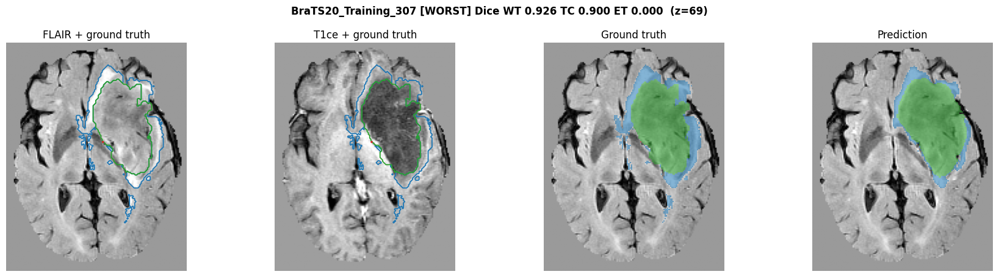

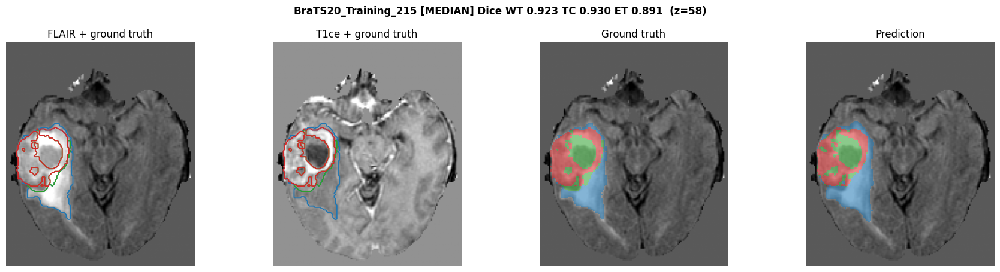

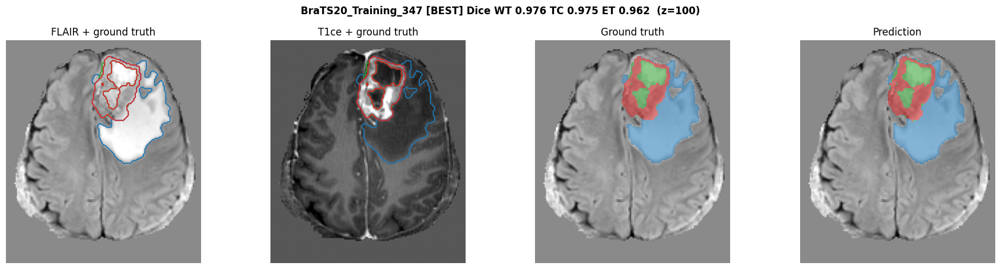

In [21]:
# ---------- 8.4 Best / median / worst cases (GT contour vs prediction contour) ----------
def show_case(pid, pred_label, title=""):
    img, seg, meta = load_cached(pid)
    z = int(np.argmax((seg > 0).sum(axis=(0, 1))))
    fig, ax = plt.subplots(1, 4, figsize=(18, 4.6))
    base_ch = CFG.MODALITIES.index("flair"); ce_ch = CFG.MODALITIES.index("t1ce")
    for a, ch, t in zip(ax[:2], [base_ch, ce_ch], ["FLAIR + ground truth", "T1ce + ground truth"]):
        a.imshow(np.rot90(img[ch, :, :, z]), cmap="gray"); a.set_title(t)
        for lab, col in [(2, "#1f77b4"), (1, "#2ca02c"), (3, "#d62728")]:
            m = np.rot90(seg[:, :, z] == lab)
            if m.any():
                a.contour(m, levels=[0.5], colors=[col], linewidths=1.3)
    for a, lab_map, t in zip(ax[2:], [seg, pred_label], ["Ground truth", "Prediction"]):
        a.imshow(np.rot90(img[base_ch, :, :, z]), cmap="gray")
        ov = np.ma.masked_where(np.rot90(lab_map[:, :, z]) == 0, np.rot90(lab_map[:, :, z]))
        a.imshow(ov, cmap=matplotlib.colors.ListedColormap(["#2ca02c", "#1f77b4", "#d62728"]), vmin=1, vmax=3,
                 alpha=0.55, interpolation="nearest")
        a.set_title(t)
    for a in ax:
        a.axis("off")
    plt.suptitle(f"{pid} {title}  (z={z})", fontweight="bold"); plt.tight_layout(); plt.show()


order = test_df.sort_values("Dice_mean").reset_index(drop=True)
picks = [("WORST", order.iloc[0]), ("MEDIAN", order.iloc[len(order) // 2]), ("BEST", order.iloc[-1])]
for tag, row in picks:
    show_case(row["id"], test_preds[row["id"]],
              f"[{tag}] Dice WT {row['Dice_WT']:.3f} TC {row['Dice_TC']:.3f} ET {row['Dice_ET']:.3f}")

# PART 9 — Tumor Size & Risk Analysis
From a predicted segmentation we measure:
* **Volumes** (cm³): whole tumor, tumor core, enhancing, necrotic core, edema
* **Size**: maximum diameter (3D Feret, mm), bounding box L×W×H, equivalent-sphere diameter
* **Burden**: tumor volume as % of brain volume
* **Location**: hemisphere, anterior/posterior, superior/inferior, distance from midline, midline crossing
* **Multifocality**: number of separate tumor components > 1 cm³
* **Risk score (0–100)** = transparent sum of 6 weighted components (see `RISK_RULES`)

⚠️ **The risk score is a research heuristic** (size + enhancement + necrosis + edema + spread). It is NOT a
clinical grading, and the model's segmentation can be wrong. Always defer to a radiologist / clinician.

In [22]:
# ============================================================
# PART 9 — SIZE + RISK
# ============================================================
from scipy.spatial import ConvexHull
from scipy.spatial.distance import pdist

# (name, max points, value at which the component saturates, unit)
RISK_RULES = [
    ("Whole-tumor volume",       30, 150.0, "cm³"),
    ("Enhancing-tumor volume",   25,  40.0, "cm³"),
    ("Necrotic fraction of core", 15,   0.6, "fraction"),
    ("Edema volume",             10, 100.0, "cm³"),
    ("Brain burden",             10,  10.0, "% of brain"),
    ("Multifocal / midline spread", 10, 1.0, "flag"),
]


def risk_category(score):
    if score < 25:
        return "LOW", "#2ca02c"
    if score < 50:
        return "MODERATE", "#f2c500"
    if score < 75:
        return "HIGH", "#ff7f0e"
    return "VERY HIGH", "#d62728"


def max_feret_mm(mask, zooms, max_pts=6000):
    """Largest 3D distance between two tumor surface voxels (mm), via convex hull."""
    s = mask & ~ndi.binary_erosion(mask, border_value=0)
    pts = np.argwhere(s).astype(np.float32) * np.asarray(zooms, np.float32)
    if len(pts) < 2:
        return float(max(zooms))
    if len(pts) > max_pts:
        pts = pts[np.random.default_rng(0).choice(len(pts), max_pts, replace=False)]
    try:
        hv = pts[ConvexHull(pts).vertices]
    except Exception:
        hv = pts
    return float(pdist(hv).max())


def size_class(d_cm):
    if d_cm < 3:
        return "Small (< 3 cm)"
    if d_cm < 5:
        return "Medium (3–5 cm)"
    if d_cm < 7:
        return "Large (5–7 cm)"
    return "Very large (> 7 cm)"


def describe_location(centroid_vox, brain_mask, wt_mask, zooms):
    """Approximate anatomical position in the (RAS+) canonical frame. x+ = Right, y+ = Anterior, z+ = Superior."""
    idx = np.argwhere(brain_mask)
    lo, hi = idx.min(0), idx.max(0)
    frac = (np.asarray(centroid_vox) - lo) / np.maximum(hi - lo, 1)
    mid_x = (lo[0] + hi[0]) / 2.0
    dx_mm = (centroid_vox[0] - mid_x) * zooms[0]
    side = "Right" if dx_mm > 0 else "Left"
    if abs(dx_mm) < 5:
        side = "Midline"
    ap = "Anterior" if frac[1] > 0.6 else ("Posterior" if frac[1] < 0.35 else "Central")
    si = "Superior" if frac[2] > 0.6 else ("Inferior" if frac[2] < 0.35 else "Mid-level")
    if frac[1] > 0.6:
        lobe = "frontal region"
    elif frac[1] < 0.25:
        lobe = "occipital region"
    elif frac[2] < 0.35:
        lobe = "temporal / deep region"
    else:
        lobe = "parietal / central region"
    left_cm3 = wt_mask[:int(mid_x)].sum() * np.prod(zooms) / 1000.0
    right_cm3 = wt_mask[int(mid_x) + 1:].sum() * np.prod(zooms) / 1000.0
    crosses = bool(left_cm3 > 1.0 and right_cm3 > 1.0)
    return {"side": side, "ap": ap, "si": si, "lobe": lobe, "dist_midline_mm": float(abs(dx_mm)),
            "crosses_midline": crosses, "frac_xyz": [float(f) for f in frac]}


def tumor_report(reg, zooms, brain_mask):
    """reg: (3,X,Y,Z) bool (WT,TC,ET) in the full canonical volume. Returns a dict with sizes, location, risk."""
    wt, tc, et = reg[0].astype(bool), reg[1].astype(bool), reg[2].astype(bool)
    vox = float(np.prod(zooms)) / 1000.0
    brain_cm3 = float(brain_mask.sum() * vox)
    r = {"zooms": list(zooms), "brain_cm3": brain_cm3}
    r["WT_cm3"], r["TC_cm3"], r["ET_cm3"] = (float(wt.sum() * vox), float(tc.sum() * vox), float(et.sum() * vox))
    r["ED_cm3"] = float((wt & ~tc).sum() * vox)
    r["NCR_cm3"] = float((tc & ~et).sum() * vox)
    r["burden_pct"] = 100.0 * r["WT_cm3"] / max(brain_cm3, 1e-6)

    if r["WT_cm3"] <= 0:
        r.update({"tumor_detected": False, "risk_score": 0.0, "risk_category": "NO TUMOR DETECTED",
                  "risk_color": "#2ca02c", "components": [], "notes": ["No tumor voxels predicted."]})
        return r

    r["tumor_detected"] = True
    bb = np.argwhere(wt)
    ext = (bb.max(0) - bb.min(0) + 1) * np.asarray(zooms)
    r["bbox_mm"] = [float(e) for e in ext]
    r["max_diameter_mm"] = max_feret_mm(wt, zooms)
    r["sphere_diameter_mm"] = float(2 * (3 * r["WT_cm3"] * 1000.0 / (4 * math.pi)) ** (1 / 3))
    r["core_max_diameter_mm"] = max_feret_mm(tc, zooms) if tc.any() else 0.0
    r["size_class"] = size_class(r["max_diameter_mm"] / 10.0)
    r["necrotic_fraction"] = r["NCR_cm3"] / r["TC_cm3"] if r["TC_cm3"] > 0 else 0.0
    r["enhancing_fraction"] = r["ET_cm3"] / r["WT_cm3"]

    cen = np.array(ndi.center_of_mass(wt))
    r["centroid_vox"] = [float(c) for c in cen]
    r["centroid_mm"] = [float(c * z) for c, z in zip(cen, zooms)]
    r["location"] = describe_location(cen, brain_mask, wt, zooms)

    lab, n = ndi.label(wt)
    sizes = ndi.sum(wt, lab, index=np.arange(1, n + 1)) * vox if n else np.array([])
    r["n_components"] = int((sizes > 1.0).sum())

    vals = {"Whole-tumor volume": r["WT_cm3"], "Enhancing-tumor volume": r["ET_cm3"],
            "Necrotic fraction of core": r["necrotic_fraction"], "Edema volume": r["ED_cm3"],
            "Brain burden": r["burden_pct"],
            "Multifocal / midline spread": 1.0 if (r["n_components"] > 1 or r["location"]["crosses_midline"]) else 0.0}
    comps, total = [], 0.0
    for name, pts, sat, unit in RISK_RULES:
        pts_got = pts * min(vals[name] / sat, 1.0)
        total += pts_got
        comps.append({"name": name, "value": float(vals[name]), "unit": unit, "points": float(pts_got), "max": pts})
    r["components"] = comps
    r["risk_score"] = float(total)
    r["risk_category"], r["risk_color"] = risk_category(total)

    notes = []
    if r["ET_cm3"] > 1.0 and r["necrotic_fraction"] > 0.1:
        notes.append("Enhancement together with a necrotic core: imaging pattern more typical of a high-grade tumor.")
    elif r["ET_cm3"] < 0.5:
        notes.append("Little or no enhancement: imaging pattern more typical of a lower-grade tumor.")
    if r["location"]["crosses_midline"]:
        notes.append("Tumor extends across the midline.")
    if r["n_components"] > 1:
        notes.append(f"{r['n_components']} separate tumor components (multifocal).")
    if r["ED_cm3"] > 60:
        notes.append("Extensive edema – possible mass effect.")
    r["notes"] = notes
    return r


def format_report(r, pid="", modality=""):
    L = []
    L.append(f"PATIENT : {pid}   |   SOURCE MRI : {modality.upper()}" if pid else "TUMOR REPORT")
    if not r["tumor_detected"]:
        L.append("RESULT  : NO TUMOR DETECTED")
        return "\n".join(L)
    loc = r["location"]
    L += [f"RISK    : {r['risk_category']}  ({r['risk_score']:.0f}/100)",
          f"SIZE    : {r['size_class']}",
          f"  max diameter      {r['max_diameter_mm'] / 10:.1f} cm   (box {r['bbox_mm'][0] / 10:.1f}×{r['bbox_mm'][1] / 10:.1f}×{r['bbox_mm'][2] / 10:.1f} cm)",
          f"  whole tumor       {r['WT_cm3']:.1f} cm³   ({r['burden_pct']:.1f}% of brain)",
          f"  tumor core        {r['TC_cm3']:.1f} cm³",
          f"  enhancing (ET)    {r['ET_cm3']:.1f} cm³   ({100 * r['enhancing_fraction']:.0f}% of tumor)",
          f"  necrotic (NCR)    {r['NCR_cm3']:.1f} cm³   ({100 * r['necrotic_fraction']:.0f}% of core)",
          f"  edema (ED)        {r['ED_cm3']:.1f} cm³",
          f"LOCATION: {loc['side']} hemisphere, {loc['ap'].lower()}-{loc['si'].lower()} ({loc['lobe']}); "
          f"{loc['dist_midline_mm']:.0f} mm from midline" + ("; CROSSES MIDLINE" if loc["crosses_midline"] else ""),
          f"COMPONENTS: {r['n_components']}",
          "RISK BREAKDOWN:"]
    for c in r["components"]:
        L.append(f"  {c['name']:<28s} {c['points']:5.1f} / {c['max']}")
    for n in r["notes"]:
        L.append(f"NOTE: {n}")
    L.append("Research heuristic – not a medical diagnosis.")
    return "\n".join(L)

# PART 10 — 3D Reconstruction **with the source MRI**
Two views are produced for any patient:
1. **Static figure (matplotlib)** – left: the *source MRI scan* (which modality is printed in the title)
   sliced through the tumor in axial / coronal / sagittal planes with tumor contours; centre: the 3D brain
   reconstructed from that MRI (translucent brain surface, tumor sub-regions, and the MRI slice itself placed
   inside the 3D scene); right: size + risk report.
2. **Interactive figure (Plotly, rotate/zoom)** – the same MRI slice panels on the left, a 3D scene on
   the right containing the brain surface, the colored tumor meshes, the **three MRI slice planes textured
   with the actual scan**, a floating label at the tumor with size & risk, and the full report box.

In [23]:
# ============================================================
# PART 10 — 3D HELPERS
# ============================================================
TUMOR_COLORS = {"ED": "#1f77b4", "NCR": "#2ca02c", "ET": "#d62728"}
TUMOR_LABELS = {"ED": "Edema", "NCR": "Necrotic core (NCR/NET)", "ET": "Enhancing tumor"}


def region_masks(reg):
    wt, tc, et = reg[0].astype(bool), reg[1].astype(bool), reg[2].astype(bool)
    return {"ED": wt & ~tc, "NCR": tc & ~et, "ET": et}


def mask_to_mesh(mask, zooms, step=2, smooth=1.0):
    """binary mask -> (verts_mm, faces) via marching cubes (None if too small)."""
    if mask.sum() < 20:
        return None
    m = ndi.gaussian_filter(mask.astype(np.float32), smooth) if smooth else mask.astype(np.float32)
    m = np.pad(m, 1)
    try:
        verts, faces, _, _ = measure.marching_cubes(m, level=0.5, spacing=tuple(zooms), step_size=step)
    except Exception:
        return None
    return verts - np.asarray(zooms), faces                     # undo the 1-voxel padding offset


def get_brain_mask(raw_vol):
    b = np.any(raw_vol != 0, axis=0)
    b = ndi.binary_closing(b, iterations=2)
    return ndi.binary_fill_holes(b)


def slice_at(vol3d, plane, idx):
    """2D slice of a 3D array. plane: 'axial' (z), 'coronal' (y), 'sagittal' (x)."""
    return {"axial": lambda: vol3d[:, :, idx], "coronal": lambda: vol3d[:, idx, :],
            "sagittal": lambda: vol3d[idx, :, :]}[plane]()


PLANE_AXES = {"axial": ("R →", "A →"), "coronal": ("R →", "S →"), "sagittal": ("A →", "S →")}


def tumor_slice_indices(reg, raw_shape):
    wt = reg[0].astype(bool)
    if wt.any():
        c = np.round(ndi.center_of_mass(wt)).astype(int)
        # snap to the slice (per plane) with the largest tumor area near the centroid
        return [int(np.clip(c[0], 0, raw_shape[0] - 1)), int(np.clip(c[1], 0, raw_shape[1] - 1)),
                int(np.clip(c[2], 0, raw_shape[2] - 1))]
    return [s // 2 for s in raw_shape]

In [24]:
# ============================================================
# PART 10a — STATIC FIGURE (matplotlib): source MRI + 3D + report
# ============================================================
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
from matplotlib.patches import Patch
from matplotlib.lines import Line2D


def plot_3d_static(mri, reg, zooms, report, pid="", modality="flair", save_path=None, show=True, mesh_step=2):
    """mri: (X,Y,Z) raw MRI of the chosen modality; reg: (3,X,Y,Z) bool prediction."""
    img = norm01(mri)
    brain = mri != 0
    brain = ndi.binary_fill_holes(ndi.binary_closing(brain, iterations=2))
    masks = region_masks(reg)
    si = tumor_slice_indices(reg, mri.shape)                    # [x, y, z]
    fig = plt.figure(figsize=(21, 10.5))
    gs = fig.add_gridspec(3, 3, width_ratios=[0.8, 1.7, 1.15], wspace=0.08, hspace=0.18)

    # ---------- LEFT: the source MRI (this is the scan the 3D brain is built from) ----------
    for r_i, (plane, idx) in enumerate(zip(["axial", "coronal", "sagittal"], [si[2], si[1], si[0]])):
        ax = fig.add_subplot(gs[r_i, 0])
        sl = np.rot90(slice_at(img, plane, idx))
        ax.imshow(sl, cmap="gray", aspect="equal")
        for key in ("ED", "NCR", "ET"):
            m = np.rot90(slice_at(masks[key], plane, idx))
            if m.any():
                ax.imshow(np.ma.masked_where(~m, m), cmap=matplotlib.colors.ListedColormap([TUMOR_COLORS[key]]),
                          alpha=0.45, interpolation="nearest")
                ax.contour(m, levels=[0.5], colors=[TUMOR_COLORS[key]], linewidths=1.1)
        ax.set_title(f"{modality.upper()} MRI – {plane}  (slice {idx})", fontsize=11, fontweight="bold")
        ax.set_xlabel(PLANE_AXES[plane][0], fontsize=8); ax.set_ylabel(PLANE_AXES[plane][1], fontsize=8)
        ax.set_xticks([]); ax.set_yticks([])
    fig.text(0.095, 0.955, "SOURCE MRI SCAN (used to build the 3D brain)", ha="left", fontsize=12,
             fontweight="bold", color="#333")

    # ---------- CENTRE: 3D brain reconstructed from that MRI ----------
    ax3 = fig.add_subplot(gs[:, 1], projection="3d")
    bm = mask_to_mesh(brain, zooms, step=3, smooth=1.5)
    if bm is not None:
        v, f = bm
        ax3.add_collection3d(Poly3DCollection(v[f], facecolor=(0.7, 0.7, 0.78, 0.10), edgecolor="none"))
    # MRI axial slice texture placed inside the 3D scene
    # place the real MRI slice just BELOW the tumor so the tumor sits on top of it and is never hidden
    z_i = si[2]
    if report["tumor_detected"]:
        z_i = int(max(np.argwhere(reg[0].astype(bool))[:, 2].min() - 3, 0))
    ds = 2
    sl = img[::ds, ::ds, z_i]
    xs = np.arange(0, img.shape[0], ds) * zooms[0]
    ys = np.arange(0, img.shape[1], ds) * zooms[1]
    XX, YY = np.meshgrid(xs, ys, indexing="ij")
    ZZ = np.full_like(XX, z_i * zooms[2])
    fc = plt.cm.gray(sl); fc[..., 3] = np.where(brain[::ds, ::ds, z_i], 0.95, 0.0)
    ax3.plot_surface(XX, YY, ZZ, facecolors=fc, rstride=1, cstride=1, shade=False, linewidth=0, antialiased=False)
    for key in ("ED", "NCR", "ET"):
        mm = mask_to_mesh(masks[key], zooms, step=mesh_step, smooth=0.8)
        if mm is None:
            continue
        v, f = mm
        a = {"ED": 0.18, "NCR": 0.65, "ET": 0.9}[key]
        ax3.add_collection3d(Poly3DCollection(v[f], facecolor=matplotlib.colors.to_rgba(TUMOR_COLORS[key], a),
                                              edgecolor="none"))
    ext = np.array(mri.shape) * np.asarray(zooms)
    ax3.set_xlim(0, ext[0]); ax3.set_ylim(0, ext[1]); ax3.set_zlim(0, ext[2])
    ax3.set_box_aspect(ext / ext.max())
    ax3.set_xlabel("R →  (mm)"); ax3.set_ylabel("A →  (mm)"); ax3.set_zlabel("S →  (mm)")
    ax3.view_init(elev=22, azim=-58)
    if report["tumor_detected"]:
        c = np.array(report["centroid_mm"])
        ax3.text(c[0], c[1], min(c[2] + 0.2 * ext[2], ext[2]),
                 f" TUMOR\n {report['WT_cm3']:.1f} cm³ | Ø {report['max_diameter_mm'] / 10:.1f} cm\n"
                 f" RISK: {report['risk_category']} ({report['risk_score']:.0f}/100)",
                 color="black", fontsize=10, fontweight="bold",
                 bbox=dict(boxstyle="round", fc="white", ec=report["risk_color"], lw=2, alpha=0.9))
        ax3.plot([c[0], c[0]], [c[1], c[1]], [c[2], min(c[2] + 0.2 * ext[2], ext[2])], color=report["risk_color"], lw=2)
    ax3.set_title(f"3D reconstruction from {modality.upper()} MRI  –  {pid}", fontsize=13, fontweight="bold")
    ax3.legend(handles=[Patch(color=TUMOR_COLORS[k], label=TUMOR_LABELS[k]) for k in ("ED", "NCR", "ET")] +
                       [Patch(color="#bbbbc4", label="Brain surface"), Patch(color="#555555", label=f"{modality.upper()} slice z={z_i}")],
               loc="upper left", fontsize=9)

    # ---------- RIGHT: report ----------
    axr = fig.add_subplot(gs[:, 2]); axr.axis("off")
    axr.text(0.0, 1.0, format_report(report, pid, modality), va="top", ha="left", family="monospace", fontsize=9.3,
             bbox=dict(boxstyle="round,pad=0.6", fc="#f7f7f9", ec=report["risk_color"], lw=2.5))
    if report["tumor_detected"]:
        axb = axr.inset_axes([0.0, 0.0, 1.0, 0.1])
        axb.barh([0], [report["risk_score"]], color=report["risk_color"], height=0.6)
        axb.barh([0], [100], color="none", edgecolor="k", height=0.6)
        for t in (25, 50, 75):
            axb.axvline(t, color="k", lw=0.6, ls=":")
        axb.set_xlim(0, 100); axb.set_yticks([]); axb.set_title("Risk score (0–100)", fontsize=9)
    if save_path:
        plt.savefig(save_path, dpi=130, bbox_inches="tight")
    if show:
        plt.show()
    else:
        plt.close(fig)
    return fig

In [25]:
# ============================================================
# PART 10b — INTERACTIVE FIGURE (Plotly): source MRI panels + rotatable 3D + report
# ============================================================
try:
    import plotly.graph_objects as go
    from plotly.subplots import make_subplots
    HAS_PLOTLY = True
except Exception:
    HAS_PLOTLY = False
    print("plotly not installed -> interactive figure disabled (pip install plotly)")


def _plane_surface(axis, idx, arr2d, brain2d, zooms, step=2):
    """A textured plane (the real MRI slice) inside the 3D scene."""
    a = arr2d[::step, ::step]
    keep = brain2d[::step, ::step]
    a = np.where(keep, a, np.nan)
    n1, n2 = a.shape
    if axis == "z":
        u = np.arange(0, arr2d.shape[0], step) * zooms[0]; v = np.arange(0, arr2d.shape[1], step) * zooms[1]
        U, V = np.meshgrid(u, v, indexing="ij"); X, Y, Z = U, V, np.full_like(U, idx * zooms[2])
    elif axis == "y":
        u = np.arange(0, arr2d.shape[0], step) * zooms[0]; v = np.arange(0, arr2d.shape[1], step) * zooms[2]
        U, V = np.meshgrid(u, v, indexing="ij"); X, Z, Y = U, V, np.full_like(U, idx * zooms[1])
    else:
        u = np.arange(0, arr2d.shape[0], step) * zooms[1]; v = np.arange(0, arr2d.shape[1], step) * zooms[2]
        U, V = np.meshgrid(u, v, indexing="ij"); Y, Z, X = U, V, np.full_like(U, idx * zooms[0])
    hole = ~keep
    X, Y, Z = (np.where(hole, np.nan, T) for T in (X, Y, Z))        # NaN coordinates -> transparent outside the brain
    a = np.nan_to_num(a, nan=0.0)
    return go.Surface(x=X, y=Y, z=Z, surfacecolor=a, colorscale="Gray", cmin=0, cmax=1, showscale=False,
                      opacity=1.0, lighting=dict(ambient=1, diffuse=0, specular=0), hoverinfo="skip")


def _mesh_trace(mesh, color, name, opacity):
    v, f = mesh
    return go.Mesh3d(x=v[:, 0], y=v[:, 1], z=v[:, 2], i=f[:, 0], j=f[:, 1], k=f[:, 2], color=color, opacity=opacity,
                     name=name, showlegend=True, flatshading=False,
                     lighting=dict(ambient=0.55, diffuse=0.7, specular=0.2), hoverinfo="name")


def plot_3d_interactive(mri, reg, zooms, report, pid="", modality="flair", save_html=None, show=True, mesh_step=2):
    if not HAS_PLOTLY:
        print("plotly missing."); return None
    img = norm01(mri)
    brain = ndi.binary_fill_holes(ndi.binary_closing(mri != 0, iterations=2))
    masks = region_masks(reg)
    si = tumor_slice_indices(reg, mri.shape)
    fig = make_subplots(rows=3, cols=2, column_widths=[0.30, 0.70], horizontal_spacing=0.02, vertical_spacing=0.07,
                        specs=[[{"type": "xy"}, {"type": "scene", "rowspan": 3}], [{"type": "xy"}, None], [{"type": "xy"}, None]],
                        subplot_titles=[f"{modality.upper()} MRI – axial", f"3D brain reconstructed from {modality.upper()} MRI",
                                        f"{modality.upper()} MRI – coronal", f"{modality.upper()} MRI – sagittal"])

    # ---- left: source MRI slices with tumor overlay ----
    for r_i, (plane, idx) in enumerate(zip(["axial", "coronal", "sagittal"], [si[2], si[1], si[0]]), start=1):
        sl = slice_at(img, plane, idx).T
        fig.add_trace(go.Heatmap(z=sl, colorscale="Gray", showscale=False, hoverinfo="skip"), row=r_i, col=1)
        lab = np.zeros_like(sl)
        for code, key in ((1, "NCR"), (2, "ED"), (3, "ET")):
            lab[slice_at(masks[key], plane, idx).T] = code
        lab = np.where(lab > 0, lab, np.nan)
        fig.add_trace(go.Heatmap(z=lab, zmin=1, zmax=3, showscale=False, opacity=0.55, hoverinfo="skip",
                                 colorscale=[[0, TUMOR_COLORS["NCR"]], [0.5, TUMOR_COLORS["ED"]], [1, TUMOR_COLORS["ET"]]]),
                      row=r_i, col=1)
        fig.update_xaxes(visible=False, row=r_i, col=1)
        fig.update_yaxes(visible=False, scaleanchor=f"x{'' if r_i == 1 else r_i}", row=r_i, col=1)

    # ---- right: 3D scene ----
    bm = mask_to_mesh(brain, zooms, step=3, smooth=1.5)
    if bm is not None:
        fig.add_trace(_mesh_trace(bm, "#c8c8d2", "Brain surface", 0.07), row=1, col=2)
    fig.add_trace(_plane_surface("z", si[2], img[:, :, si[2]], brain[:, :, si[2]], zooms), row=1, col=2)
    fig.add_trace(_plane_surface("y", si[1], img[:, si[1], :], brain[:, si[1], :], zooms), row=1, col=2)
    fig.add_trace(_plane_surface("x", si[0], img[si[0], :, :], brain[si[0], :, :], zooms), row=1, col=2)
    for key in ("ED", "NCR", "ET"):
        mm = mask_to_mesh(masks[key], zooms, step=mesh_step, smooth=0.8)
        if mm is not None:
            fig.add_trace(_mesh_trace(mm, TUMOR_COLORS[key], TUMOR_LABELS[key], {"ED": 0.25, "NCR": 0.7, "ET": 0.95}[key]),
                          row=1, col=2)
    ext = np.array(mri.shape) * np.asarray(zooms)
    if report["tumor_detected"]:
        c = np.array(report["centroid_mm"]); top = np.array([c[0], c[1], min(c[2] + 0.28 * ext[2], ext[2])])
        fig.add_trace(go.Scatter3d(x=[c[0], top[0]], y=[c[1], top[1]], z=[c[2], top[2]], mode="lines",
                                   line=dict(color=report["risk_color"], width=6), showlegend=False, hoverinfo="skip"),
                      row=1, col=2)
        fig.add_trace(go.Scatter3d(
            x=[top[0]], y=[top[1]], z=[top[2]], mode="text", showlegend=False, hoverinfo="skip",
            text=[f"<b>TUMOR</b><br>{report['WT_cm3']:.1f} cm³ | Ø {report['max_diameter_mm'] / 10:.1f} cm"
                  f"<br><b>RISK: {report['risk_category']} ({report['risk_score']:.0f}/100)</b>"],
            textfont=dict(size=14, color=report["risk_color"])), row=1, col=2)
    fig.update_scenes(aspectmode="data", xaxis_title="R → (mm)", yaxis_title="A → (mm)", zaxis_title="S → (mm)",
                      camera=dict(eye=dict(x=1.5, y=-1.6, z=0.9)), bgcolor="rgb(245,245,248)")

    rep_html = format_report(report, pid, modality).replace("\n", "<br>").replace(" ", "&nbsp;")
    fig.add_annotation(xref="paper", yref="paper", x=0.995, y=0.995, xanchor="right", yanchor="top", align="left",
                       text=f"<span style='font-family:monospace;font-size:11px'>{rep_html}</span>",
                       showarrow=False, bgcolor="rgba(255,255,255,0.88)", bordercolor=report["risk_color"], borderwidth=2)
    fig.update_layout(title=dict(text=f"<b>{pid}</b> — source MRI: <b>{modality.upper()}</b> → 3D brain & tumor "
                                      f"(rotate / zoom with the mouse)", x=0.5),
                      height=820, margin=dict(l=10, r=10, t=70, b=10),
                      legend=dict(x=0.31, y=0.02, bgcolor="rgba(255,255,255,0.7)"))
    if save_html:
        fig.write_html(save_html, include_plotlyjs="cdn")
    if show:
        fig.show()
    return fig

# PART 11 — One call: give a patient path → size, risk, 3D report
`analyze_patient("/path/to/BraTS20_Training_001")` will
1. load the 4 MRI sequences (`flair, t1, t1ce, t2` – labels/seg file NOT needed),
2. preprocess → predict with the trained network → post-process,
3. print the **tumor size & risk report**,
4. draw the **source MRI + 3D reconstruction + report** (static PNG and interactive HTML),
5. save the predicted segmentation as NIfTI (`BraTS labels 1,2,4`, same affine as the canonical scan).
If a ground-truth `*_seg.nii` is in the folder, Dice/HD95 against it are printed as well.

In [26]:
# ============================================================
# PART 11 — INFERENCE ON A PATH
# ============================================================
def resolve_patient_dir(path):
    """Accepts a patient folder OR any NIfTI file inside it."""
    path = str(path)
    return os.path.dirname(path) if os.path.isfile(path) else path


def predict_full_volume(model, raw_vol, tta=True, overlap=None):
    """raw_vol (4,X,Y,Z) canonical raw -> bool prediction (3,X,Y,Z) in the same (full) space."""
    img, _, bb = preprocess_volume(raw_vol, None)
    prob = sliding_window_predict(model, img, overlap=overlap or CFG.SW_OVERLAP_TEST, tta=tta)
    pred = postprocess(prob)
    full = np.zeros((3,) + raw_vol.shape[1:], bool)
    full[(slice(None),) + bb] = pred
    return full


def analyze_patient(path, model=None, modality=None, save_dir=None, show=True, interactive=True, tta=True):
    """Full pipeline for ONE patient folder. Returns dict(report, reg, label_map, paths)."""
    modality = (modality or CFG.DISPLAY_MODALITY).lower()
    assert modality in CFG.MODALITIES, f"modality must be one of {CFG.MODALITIES}"
    pdir = resolve_patient_dir(path)
    files = find_patient_files(pdir)
    missing = [m for m in CFG.MODALITIES if m not in files]
    if missing:
        raise FileNotFoundError(f"{pdir}: missing MRI sequences {missing}. Found: {list(files)}")
    pid = os.path.basename(os.path.normpath(pdir))
    model = model or load_model()
    save_dir = save_dir or os.path.join(CFG.OUT_DIR, "reports", pid)
    os.makedirs(save_dir, exist_ok=True)

    t0 = time.time()
    raw, seg_gt, zooms, affine = load_patient_raw(files, with_seg=True)
    reg = predict_full_volume(model, raw, tta=tta)
    brain = get_brain_mask(raw)
    rep = tumor_report(reg, zooms, brain)
    mri = raw[CFG.MODALITIES.index(modality)]

    print("=" * 78); print(format_report(rep, pid, modality)); print("=" * 78)
    print(f"(inference + analysis: {time.time() - t0:.1f}s)")

    out = {"id": pid, "report": rep, "reg": reg, "label_map": regions_to_seg(reg[0], reg[1], reg[2]), "paths": {}}
    if seg_gt is not None:                                       # ground truth available -> compare
        gt = seg_to_regions(seg_gt).astype(bool)
        m = region_metrics(reg, gt, zooms, hd=True)
        out["metrics_vs_gt"] = m
        print("Ground-truth comparison  Dice  WT {:.3f} | TC {:.3f} | ET {:.3f}   HD95(mm)  WT {:.1f} | TC {:.1f} | ET {:.1f}".format(
            m["Dice_WT"], m["Dice_TC"], m["Dice_ET"], m["HD95_WT"], m["HD95_TC"], m["HD95_ET"]))

    nii_path = os.path.join(save_dir, f"{pid}_pred_seg.nii.gz")
    nib.save(nib.Nifti1Image(out["label_map"], affine), nii_path); out["paths"]["segmentation"] = nii_path
    json_path = os.path.join(save_dir, f"{pid}_report.json")
    with open(json_path, "w") as f:
        json.dump(rep, f, indent=1, default=lambda o: o.item() if hasattr(o, "item") else str(o))
    out["paths"]["report_json"] = json_path

    png = os.path.join(save_dir, f"{pid}_3d_{modality}.png")
    plot_3d_static(mri, reg, zooms, rep, pid=pid, modality=modality, save_path=png, show=show)
    out["paths"]["figure_png"] = png
    if interactive and HAS_PLOTLY:
        html = os.path.join(save_dir, f"{pid}_3d_{modality}.html")
        plot_3d_interactive(mri, reg, zooms, rep, pid=pid, modality=modality, save_html=html, show=show)
        out["paths"]["figure_html"] = html
    print("Saved:", json.dumps(out["paths"], indent=1))
    out["_raw"], out["_zooms"] = raw, zooms
    return out


def show_all_modalities(result, n_planes=("axial",)):
    """Optional: all four MRI sequences through the tumor, with the predicted contours (which scan shows what)."""
    raw, reg = result["_raw"], result["reg"]
    masks = region_masks(reg); si = tumor_slice_indices(reg, raw.shape[1:])
    fig, ax = plt.subplots(len(n_planes), 4, figsize=(17, 4.4 * len(n_planes)), squeeze=False)
    for r_i, plane in enumerate(n_planes):
        idx = {"axial": si[2], "coronal": si[1], "sagittal": si[0]}[plane]
        for c, m in enumerate(CFG.MODALITIES):
            ax[r_i, c].imshow(np.rot90(slice_at(norm01(raw[c]), plane, idx)), cmap="gray")
            for key in ("ED", "NCR", "ET"):
                mk = np.rot90(slice_at(masks[key], plane, idx))
                if mk.any():
                    ax[r_i, c].contour(mk, levels=[0.5], colors=[TUMOR_COLORS[key]], linewidths=1.2)
            ax[r_i, c].set_title(f"{m.upper()} – {plane} {idx}"); ax[r_i, c].axis("off")
    plt.suptitle(f"{result['id']} — all MRI sequences with predicted tumor contours", fontweight="bold")
    plt.tight_layout(); plt.show()

PATIENT : BraTS20_Training_190   |   SOURCE MRI : FLAIR
RISK    : LOW  (25/100)
SIZE    : Large (5–7 cm)
  max diameter      6.6 cm   (box 4.5×5.8×5.4 cm)
  whole tumor       45.6 cm³   (3.3% of brain)
  tumor core        12.4 cm³
  enhancing (ET)    11.5 cm³   (25% of tumor)
  necrotic (NCR)    0.9 cm³   (7% of core)
  edema (ED)        33.3 cm³
LOCATION: Left hemisphere, anterior-mid-level (frontal region); 40 mm from midline
COMPONENTS: 1
RISK BREAKDOWN:
  Whole-tumor volume             9.1 / 30
  Enhancing-tumor volume         7.2 / 25
  Necrotic fraction of core      1.9 / 15
  Edema volume                   3.3 / 10
  Brain burden                   3.3 / 10
  Multifocal / midline spread    0.0 / 10
Research heuristic – not a medical diagnosis.
(inference + analysis: 20.8s)
Ground-truth comparison  Dice  WT 0.927 | TC 0.827 | ET 0.840   HD95(mm)  WT 3.0 | TC 3.7 | ET 3.0


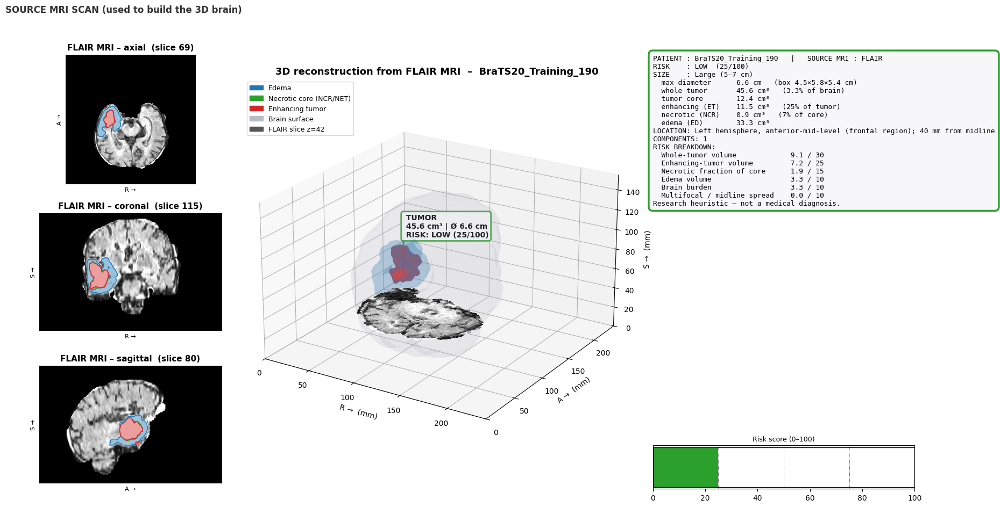

Saved: {
 "segmentation": "/kaggle/working/outputs/reports/BraTS20_Training_190/BraTS20_Training_190_pred_seg.nii.gz",
 "report_json": "/kaggle/working/outputs/reports/BraTS20_Training_190/BraTS20_Training_190_report.json",
 "figure_png": "/kaggle/working/outputs/reports/BraTS20_Training_190/BraTS20_Training_190_3d_flair.png",
 "figure_html": "/kaggle/working/outputs/reports/BraTS20_Training_190/BraTS20_Training_190_3d_flair.html"
}


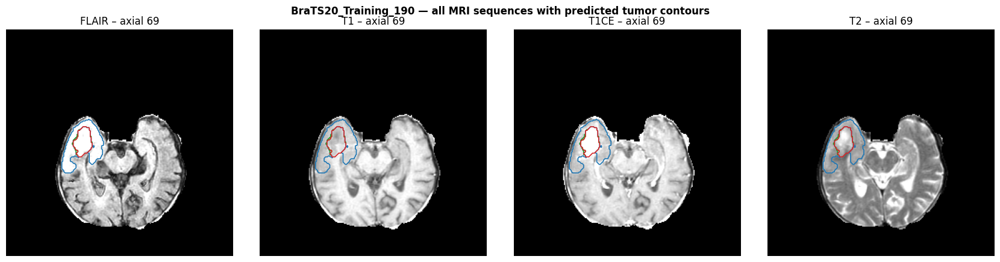

In [27]:
# ---------- 11.1 EXAMPLE: give a path, get size + risk + 3D (source MRI shown beside the 3D brain) ----------
# Replace the path with ANY patient folder (training or validation set) – only the 4 MRI files are required.
EXAMPLE_PATH = pid2patient[ids_test[0]]["dir"]
# EXAMPLE_PATH = "/kaggle/input/datasets/awsaf49/brats20-dataset-training-validation/BraTS2020_ValidationData/MICCAI_BraTS2020_ValidationData/BraTS20_Validation_001"

result = analyze_patient(EXAMPLE_PATH, model=model, modality="flair")      # modality: flair | t1 | t1ce | t2
show_all_modalities(result)

PATIENT : BraTS20_Training_190   |   SOURCE MRI : T1CE
RISK    : LOW  (25/100)
SIZE    : Large (5–7 cm)
  max diameter      6.6 cm   (box 4.5×5.8×5.4 cm)
  whole tumor       45.6 cm³   (3.3% of brain)
  tumor core        12.4 cm³
  enhancing (ET)    11.5 cm³   (25% of tumor)
  necrotic (NCR)    0.9 cm³   (7% of core)
  edema (ED)        33.3 cm³
LOCATION: Left hemisphere, anterior-mid-level (frontal region); 40 mm from midline
COMPONENTS: 1
RISK BREAKDOWN:
  Whole-tumor volume             9.1 / 30
  Enhancing-tumor volume         7.2 / 25
  Necrotic fraction of core      1.9 / 15
  Edema volume                   3.3 / 10
  Brain burden                   3.3 / 10
  Multifocal / midline spread    0.0 / 10
Research heuristic – not a medical diagnosis.
(inference + analysis: 5.6s)
Ground-truth comparison  Dice  WT 0.927 | TC 0.827 | ET 0.840   HD95(mm)  WT 3.0 | TC 3.7 | ET 3.0


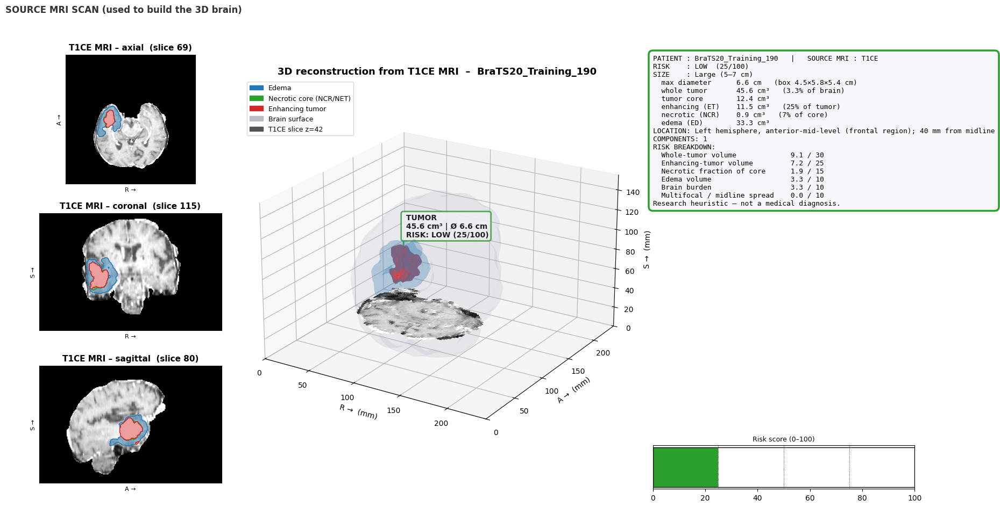

Saved: {
 "segmentation": "/kaggle/working/outputs/reports/BraTS20_Training_190/BraTS20_Training_190_pred_seg.nii.gz",
 "report_json": "/kaggle/working/outputs/reports/BraTS20_Training_190/BraTS20_Training_190_report.json",
 "figure_png": "/kaggle/working/outputs/reports/BraTS20_Training_190/BraTS20_Training_190_3d_t1ce.png",
 "figure_html": "/kaggle/working/outputs/reports/BraTS20_Training_190/BraTS20_Training_190_3d_t1ce.html"
}


In [28]:
# ---------- 11.2 Same patient, other MRI sequence as the 3D "source image" ----------
# The 3D tumor is identical; only the MRI scan shown next to / inside the 3D brain changes.
result_t1ce = analyze_patient(EXAMPLE_PATH, model=model, modality="t1ce", interactive=True)

In [29]:
# ---------- 11.3 Risk ranking of all test patients ----------
rows = []
for pid, pl in test_preds.items():
    meta = cache_meta[pid]
    reg = np.stack([pl > 0, (pl == 1) | (pl == 3), pl == 3])
    brain_c = np.any(np.load(cache_paths(pid)["img"]).astype(np.float32) != 0, axis=0)
    rep = tumor_report(reg, tuple(meta["zooms"]), brain_c)
    rows.append({"id": pid, "risk_score": rep["risk_score"], "risk": rep["risk_category"], "WT_cm3": rep["WT_cm3"],
                 "ET_cm3": rep["ET_cm3"], "max_diam_cm": rep.get("max_diameter_mm", 0) / 10,
                 "size_class": rep.get("size_class", "-")})
risk_df = pd.DataFrame(rows).sort_values("risk_score", ascending=False)
risk_df.to_csv(os.path.join(CFG.OUT_DIR, "test_risk_ranking.csv"), index=False)
print(risk_df.round(2).head(15).to_string(index=False))
print("\nRisk categories:", risk_df["risk"].value_counts().to_dict())

                  id  risk_score      risk  WT_cm3  ET_cm3  max_diam_cm          size_class
BraTS20_Training_369       94.45 VERY HIGH  225.59   44.07        16.49 Very large (> 7 cm)
BraTS20_Training_152       88.25 VERY HIGH  178.89   31.14        10.13 Very large (> 7 cm)
BraTS20_Training_175       87.55 VERY HIGH  181.84   81.67        10.48 Very large (> 7 cm)
BraTS20_Training_150       84.70 VERY HIGH  145.00   49.81         8.96 Very large (> 7 cm)
BraTS20_Training_100       80.01 VERY HIGH  140.71   34.78        10.05 Very large (> 7 cm)
BraTS20_Training_258       79.68 VERY HIGH  116.61   32.98         7.47 Very large (> 7 cm)
BraTS20_Training_273       77.28 VERY HIGH  212.52    3.65        14.01 Very large (> 7 cm)
BraTS20_Training_347       72.23      HIGH  114.54   24.54         9.67 Very large (> 7 cm)
BraTS20_Training_236       69.96      HIGH  153.50   12.89        10.44 Very large (> 7 cm)
BraTS20_Training_072       68.95      HIGH  122.18   37.51         9.65 Very lar

# PART 12 — Predict the unlabeled BraTS validation set
Writes one segmentation NIfTI per patient (labels 1, 2, 4 – BraTS submission format) and a CSV with
size + risk for every patient. The BraTS validation set has **no ground truth**, so no Dice is computed here
(upload the NIfTIs to the official BraTS portal for scoring).

In [30]:
# ============================================================
# PART 12 — BATCH PREDICTION (validation set, no labels)
# ============================================================
def predict_unlabeled(patients, model, out_dir=None, limit=None, tta=True):
    out_dir = out_dir or os.path.join(CFG.OUT_DIR, "validation_predictions")
    os.makedirs(out_dir, exist_ok=True)
    rows = []
    for pt in tqdm(patients[:limit] if limit else patients, desc="predict"):
        raw, _, zooms, affine = load_patient_raw(pt["files"], with_seg=False)
        reg = predict_full_volume(model, raw, tta=tta)
        rep = tumor_report(reg, zooms, get_brain_mask(raw))
        nib.save(nib.Nifti1Image(regions_to_seg(reg[0], reg[1], reg[2]), affine), os.path.join(out_dir, pt["id"] + ".nii.gz"))
        rows.append({"id": pt["id"], "WT_cm3": rep["WT_cm3"], "TC_cm3": rep["TC_cm3"], "ET_cm3": rep["ET_cm3"],
                     "ED_cm3": rep["ED_cm3"], "NCR_cm3": rep["NCR_cm3"], "burden_pct": rep["burden_pct"],
                     "max_diameter_cm": rep.get("max_diameter_mm", 0) / 10, "risk_score": rep["risk_score"],
                     "risk": rep["risk_category"]})
        del raw, reg
    df = pd.DataFrame(rows)
    df.to_csv(os.path.join(out_dir, "validation_size_risk.csv"), index=False)
    return df


if val_patients_unlabeled:
    val_pred_df = predict_unlabeled(val_patients_unlabeled, model, limit=None)     # set limit=5 for a quick test
    print(val_pred_df.round(2).head(10).to_string(index=False))
    print("Risk categories:", val_pred_df["risk"].value_counts().to_dict())
else:
    print("No unlabeled validation folder found – skipped.")

predict:   0%|          | 0/125 [00:00<?, ?it/s]

                    id  WT_cm3  TC_cm3  ET_cm3  ED_cm3  NCR_cm3  burden_pct  max_diameter_cm  risk_score      risk
BraTS20_Validation_001  110.50   20.77   19.64   89.72     1.14        6.91             8.96       51.63      HIGH
BraTS20_Validation_002   32.56   12.80    8.76   19.76     4.04        1.76             5.10       23.62       LOW
BraTS20_Validation_003   52.23   10.51    8.89   41.72     1.62        3.74             6.62       27.76  MODERATE
BraTS20_Validation_004  143.03   97.17   49.09   45.86    48.08        9.66             9.61       90.22 VERY HIGH
BraTS20_Validation_005   73.62   34.63    1.73   39.00    32.90        4.57             7.52       39.28  MODERATE
BraTS20_Validation_006  131.92   29.06   13.51  102.86    15.55        8.56             9.33       66.76      HIGH
BraTS20_Validation_007  115.16   53.57   29.38   61.59    24.20        8.53             8.73       67.37      HIGH
BraTS20_Validation_008  162.81   57.75   42.99  105.06    14.76       11.13     

In [31]:
# ---------- Final summary ----------
print("\nALL DONE.  Outputs are in:", CFG.OUT_DIR)
for f in sorted(glob.glob(os.path.join(CFG.OUT_DIR, "*")))[:30]:
    print("  ", os.path.relpath(f, CFG.WORK_DIR))
print("Best checkpoint:", CKPT_BEST)


ALL DONE.  Outputs are in: /kaggle/working/outputs
   outputs/eda_overview.png
   outputs/eda_summary.csv
   outputs/reports
   outputs/split.json
   outputs/test_confusion_matrix.png
   outputs/test_metric_boxplots.png
   outputs/test_metrics_per_patient.csv
   outputs/test_metrics_summary.csv
   outputs/test_risk_ranking.csv
   outputs/test_volume_agreement.png
   outputs/training_curves.png
   outputs/training_history.csv
   outputs/validation_predictions
Best checkpoint: /kaggle/working/checkpoints/best.pt


In [32]:
import os

print(os.path.exists("/kaggle/working/checkpoints/best.pt"))
print(os.path.getsize("/kaggle/working/checkpoints/best.pt") / (1024**2), "MB")

True
72.74279117584229 MB


In [33]:
import torch

CKPT_BEST = "/kaggle/working/checkpoints/best.pt"

ckpt = torch.load(
    CKPT_BEST,
    map_location="cpu"
)

print("Checkpoint type:", type(ckpt))

if isinstance(ckpt, dict):
    print("\nCheckpoint keys:")
    for k, v in ckpt.items():
        print(f"{k}: {type(v)}")
else:
    print("Checkpoint is not a dictionary.")

Checkpoint type: <class 'dict'>

Checkpoint keys:
model: <class 'collections.OrderedDict'>
opt: <class 'dict'>
scaler: <class 'dict'>
epoch: <class 'int'>
history: <class 'list'>
best: <class 'float'>
bad: <class 'int'>
base: <class 'int'>
patch: <class 'tuple'>
modalities: <class 'list'>


In [37]:
CKPT_BEST = "/kaggle/working/checkpoints/best.pt"

In [44]:
import torch

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

CKPT_PATH = "/kaggle/working/checkpoints/best.pt"

ckpt = torch.load(
    CKPT_PATH,
    map_location=DEVICE
)

print("Checkpoint loaded!")
print("Best epoch :", ckpt["epoch"])
print("Best Dice  :", ckpt["best"])
print("Patch      :", ckpt["patch"])
print("Modalities :", ckpt["modalities"])


model.load_state_dict(ckpt["model"])

model.eval()

print(" Best model loaded successfully!")

Checkpoint loaded!
Best epoch : 99
Best Dice  : 0.8347390613082616
Patch      : (128, 128, 128)
Modalities : ['flair', 't1', 't1ce', 't2']
 Best model loaded successfully!
